# 07 — Performance and Short-Side Attribution

This notebook investigates the economic sources of portfolio performance and risk after selecting the implementation frequencies in Notebook 06.

It addresses two related questions:

1. What drives the historical performance and risk of the selected implementations?
2. Does the short side provide independent cross-sectional alpha, or does it primarily reduce market exposure and mitigate drawdowns?

The analysis covers:

1. input and return-reproduction audits;
2. portfolio, long-side, short-side and transaction-cost attribution;
3. full-sample and rolling market-risk diagnostics;
4. security-level exposure and concentration;
5. drawdown and stress-event attribution;
6. comparison of the selected short books with same-notional short-SPY hedges;
7. conditional short-side behaviour across market regimes; and
8. market-beta and short-selection regressions.

Composite Score rebalanced every 21 trading days is the primary specification. Fixed 50/50 Sleeves and Pure Inverse Volatility, each rebalanced every 10 trading days, are retained as transparent implementation benchmarks. Offset zero is used as a deterministic calendar convention rather than an optimised phase.

This notebook provides historical attribution rather than a live monitoring system. Notebook 08 converts the resulting evidence into a time-varying strategy-health framework covering retained signals, risk exposures, concentration, implementation quality and diagnostic flags.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from IPython.display import display

from alpha_research.config.paths import (
    PROCESSED_DATA_DIR,
)
from alpha_research.data_loader import (
    load_parquet,
)

pd.set_option(
    "display.max_columns",
    100,
)
pd.set_option(
    "display.width",
    160,
)

sns.set_theme(
    style="whitegrid",
    context="notebook",
)

TRADING_DAYS_PER_YEAR = 252
ATTRIBUTION_TOLERANCE = 1e-12

## 1. Inputs and attribution convention

For each security and date, `weight` is the post-trade portfolio weight that earns `asset_return` on that date. `pre_trade_weight` is the drifted weight immediately before any rebalance, and `trade = weight - pre_trade_weight`.

Security gross contribution is therefore `weight × realised_asset_return`. Missing returns are treated as zero, matching the backtest engine. Security-level transaction cost is `abs(trade) × 10 bps`, so security net contributions reconcile exactly to portfolio net return.

### Import and audit datasets

In [2]:
selected_implementations = load_parquet(
    PROCESSED_DATA_DIR / "attribution_selected_implementations.parquet"
)

portfolio_daily = load_parquet(
    PROCESSED_DATA_DIR / "attribution_portfolio_daily.parquet"
)

security_daily = load_parquet(PROCESSED_DATA_DIR / "attribution_security_daily.parquet")

target_weights = load_parquet(PROCESSED_DATA_DIR / "attribution_target_weights.parquet")

benchmark_daily = load_parquet(
    PROCESSED_DATA_DIR / "attribution_benchmark_daily.parquet"
)

for dataset in [
    portfolio_daily,
    security_daily,
    target_weights,
    benchmark_daily,
]:
    dataset["date"] = pd.to_datetime(dataset["date"])

In [3]:
REQUIRED_COLUMNS = {
    "selected_implementations": {
        "portfolio",
        "rebalance_frequency",
        "rebalance_offset",
        "role",
    },
    "portfolio_daily": {
        "portfolio",
        "rebalance_frequency",
        "rebalance_offset",
        "date",
        "long_return",
        "short_return",
        "gross_return",
        "transaction_cost",
        "net_return",
        "turnover",
    },
    "security_daily": {
        "portfolio",
        "rebalance_frequency",
        "rebalance_offset",
        "date",
        "ticker",
        "pre_trade_weight",
        "weight",
        "trade",
        "asset_return",
        "gross_contribution",
        "net_contribution",
    },
    "target_weights": {
        "portfolio",
        "rebalance_frequency",
        "rebalance_offset",
        "date",
        "ticker",
        "weight",
    },
    "benchmark_daily": {
        "date",
        "benchmark",
        "benchmark_return",
    },
}

ATTRIBUTION_DATASETS = {
    "selected_implementations": (selected_implementations),
    "portfolio_daily": portfolio_daily,
    "security_daily": security_daily,
    "target_weights": target_weights,
    "benchmark_daily": benchmark_daily,
}

for dataset_name, dataset in ATTRIBUTION_DATASETS.items():
    missing_columns = REQUIRED_COLUMNS[dataset_name] - set(dataset.columns)

    if missing_columns:
        raise ValueError(
            f"{dataset_name} is missing columns: " f"{sorted(missing_columns)}"
        )

In [4]:
duplicate_key_counts = {
    "selected_implementations": (
        selected_implementations.duplicated(
            [
                "portfolio",
                "rebalance_frequency",
                "rebalance_offset",
            ],
            keep=False,
        ).sum()
    ),
    "portfolio_daily": (
        portfolio_daily.duplicated(
            [
                "portfolio",
                "date",
            ],
            keep=False,
        ).sum()
    ),
    "security_daily": (
        security_daily.duplicated(
            [
                "portfolio",
                "date",
                "ticker",
            ],
            keep=False,
        ).sum()
    ),
    "target_weights": (
        target_weights.duplicated(
            [
                "portfolio",
                "date",
                "ticker",
            ],
            keep=False,
        ).sum()
    ),
    "benchmark_daily": (
        benchmark_daily.duplicated(
            ["date"],
            keep=False,
        ).sum()
    ),
}

input_audit = pd.DataFrame(
    [
        {
            "dataset": dataset_name,
            "rows": len(dataset),
            "columns": len(dataset.columns),
            "start_date": (
                dataset["date"].min() if "date" in dataset.columns else pd.NaT
            ),
            "end_date": (
                dataset["date"].max() if "date" in dataset.columns else pd.NaT
            ),
            "duplicate_key_rows": (duplicate_key_counts[dataset_name]),
        }
        for dataset_name, dataset in (ATTRIBUTION_DATASETS.items())
    ]
)

display(input_audit)

if any(count > 0 for count in duplicate_key_counts.values()):
    raise ValueError("Duplicate attribution keys found.")

,dataset,rows,columns,start_date,end_date,duplicate_key_rows
0,selected_implementations,3,4,NaT,NaT,0
1,portfolio_daily,7905,20,2016-01-07,2026-07-01,0
2,security_daily,407676,23,2016-01-07,2026-07-01,0
3,target_weights,64088,7,2016-01-14,2026-06-17,0
4,benchmark_daily,2635,3,2016-01-07,2026-07-01,0


In [5]:
portfolio_daily_analysis = (
    portfolio_daily.merge(
        benchmark_daily,
        on="date",
        how="left",
        validate="many_to_one",
    )
    .sort_values(
        [
            "portfolio",
            "date",
        ]
    )
    .reset_index(drop=True)
)

analysis_sample_audit = portfolio_daily_analysis.groupby(
    "portfolio",
    sort=False,
).agg(
    observations=("date", "size"),
    start_date=("date", "min"),
    end_date=("date", "max"),
    missing_benchmark_returns=(
        "benchmark_return",
        lambda values: values.isna().sum(),
    ),
)

display(analysis_sample_audit)

if portfolio_daily_analysis["benchmark_return"].isna().any():
    raise ValueError("Missing benchmark returns in the " "analysis sample.")

,observations,start_date,end_date,missing_benchmark_returns
portfolio,,,,
Composite Score,2635,2016-01-07,2026-07-01,0
Fixed 50/50 Sleeves,2635,2016-01-07,2026-07-01,0
Pure Inverse Volatility,2635,2016-01-07,2026-07-01,0


## 2. Portfolio performance and market attribution

This section establishes the selected implementations' overall performance before examining more granular attribution.

The analysis separates:

1. compounded gross and net portfolio performance;
2. arithmetic return contributions from the long side, short side and transaction costs;
3. cumulative wealth and drawdowns; and
4. market exposure relative to SPY.

Long-, short- and cost-level results are treated as additive return contributions rather than standalone investable return series. Consequently, they are annualised using arithmetic means, while portfolio-level returns are compounded geometrically.

#### Helpers

In [6]:
PORTFOLIO_ORDER = selected_implementations["portfolio"].tolist()


def annualised_geometric_return(
    returns,
    periods_per_year=TRADING_DAYS_PER_YEAR,
):
    returns = pd.Series(returns).dropna()

    if returns.empty:
        return np.nan

    total_growth = (1.0 + returns).prod()

    if total_growth <= 0.0:
        return np.nan

    return total_growth ** (periods_per_year / len(returns)) - 1.0


def annualised_volatility(
    returns,
    periods_per_year=TRADING_DAYS_PER_YEAR,
):
    returns = pd.Series(returns).dropna()

    if len(returns) < 2:
        return np.nan

    return returns.std(ddof=1) * np.sqrt(periods_per_year)


def annualised_sharpe_ratio(
    returns,
    periods_per_year=TRADING_DAYS_PER_YEAR,
):
    returns = pd.Series(returns).dropna()

    if len(returns) < 2:
        return np.nan

    daily_volatility = returns.std(ddof=1)

    if np.isclose(daily_volatility, 0.0):
        return np.nan

    return returns.mean() / daily_volatility * np.sqrt(periods_per_year)


def maximum_drawdown(returns):
    returns = pd.Series(returns).dropna()

    if returns.empty:
        return np.nan

    wealth = (1.0 + returns).cumprod()

    running_peak = pd.Series(
        np.maximum.accumulate(np.r_[1.0, wealth.to_numpy()])[1:],
        index=wealth.index,
    )

    drawdown = wealth / running_peak - 1.0

    return drawdown.min()


def summarise_return_series(returns):
    returns = pd.Series(returns).dropna()

    return {
        "observations": len(returns),
        "total_return": ((1.0 + returns).prod() - 1.0),
        "annualised_return": (annualised_geometric_return(returns)),
        "annualised_volatility": (annualised_volatility(returns)),
        "sharpe_ratio": (annualised_sharpe_ratio(returns)),
        "maximum_drawdown": (maximum_drawdown(returns)),
        "positive_day_fraction": (returns.gt(0.0).mean()),
    }

#### Gross, net and benchmark performance

In [7]:
performance_summary_rows = []

RETURN_STREAMS = {
    "Gross": "gross_return",
    "Net": "net_return",
}

for portfolio_name in PORTFOLIO_ORDER:
    portfolio_data = portfolio_daily_analysis.loc[
        portfolio_daily_analysis["portfolio"].eq(portfolio_name)
    ].sort_values("date")

    for return_stream, return_column in RETURN_STREAMS.items():
        performance_summary_rows.append(
            {
                "portfolio": portfolio_name,
                "return_stream": return_stream,
                **summarise_return_series(portfolio_data[return_column]),
            }
        )

performance_summary_rows.append(
    {
        "portfolio": "SPY",
        "return_stream": "Benchmark",
        **summarise_return_series(benchmark_daily["benchmark_return"]),
    }
)

performance_summary = pd.DataFrame(performance_summary_rows)

performance_summary["portfolio"] = pd.Categorical(
    performance_summary["portfolio"],
    categories=[
        *PORTFOLIO_ORDER,
        "SPY",
    ],
    ordered=True,
)

performance_summary = performance_summary.sort_values(
    [
        "portfolio",
        "return_stream",
    ]
).reset_index(drop=True)

display(
    performance_summary.style.format(
        {
            "total_return": "{:.2%}",
            "annualised_return": "{:.2%}",
            "annualised_volatility": "{:.2%}",
            "sharpe_ratio": "{:.3f}",
            "maximum_drawdown": "{:.2%}",
            "positive_day_fraction": "{:.2%}",
        }
    )
)

,portfolio,return_stream,observations,total_return,annualised_return,annualised_volatility,sharpe_ratio,maximum_drawdown,positive_day_fraction
0,Composite Score,Gross,2635,446.07%,17.63%,21.16%,0.874,-28.73%,55.41%
1,Composite Score,Net,2635,377.48%,16.13%,21.17%,0.813,-29.24%,55.29%
2,Fixed 50/50 Sleeves,Gross,2635,245.81%,12.60%,16.77%,0.792,-23.96%,54.84%
3,Fixed 50/50 Sleeves,Net,2635,193.43%,10.84%,16.77%,0.698,-25.68%,54.38%
4,Pure Inverse Volatility,Gross,2635,253.01%,12.82%,16.25%,0.824,-21.23%,55.29%
5,Pure Inverse Volatility,Net,2635,196.65%,10.96%,16.25%,0.722,-21.77%,54.76%
6,SPY,Benchmark,2635,353.38%,15.55%,17.83%,0.900,-33.72%,55.45%


#### Audit the additive attribution identities

In [8]:
side_cost_reconciliation_rows = []

for portfolio_name in PORTFOLIO_ORDER:
    portfolio_data = portfolio_daily_analysis.loc[
        portfolio_daily_analysis["portfolio"].eq(portfolio_name)
    ]

    long_short_difference = (
        (
            portfolio_data["long_return"]
            + portfolio_data["short_return"]
            - portfolio_data["gross_return"]
        )
        .abs()
        .max()
    )

    cost_difference = (
        (
            portfolio_data["gross_return"]
            - portfolio_data["transaction_cost"]
            - portfolio_data["net_return"]
        )
        .abs()
        .max()
    )

    side_cost_reconciliation_rows.append(
        {
            "portfolio": portfolio_name,
            "max_abs_long_short_difference": (long_short_difference),
            "max_abs_cost_difference": (cost_difference),
            "audit_passes": (
                long_short_difference < ATTRIBUTION_TOLERANCE
                and cost_difference < ATTRIBUTION_TOLERANCE
            ),
        }
    )

side_cost_reconciliation = pd.DataFrame(side_cost_reconciliation_rows).set_index(
    "portfolio"
)

display(side_cost_reconciliation)

if not side_cost_reconciliation["audit_passes"].all():
    raise ValueError("Portfolio side/cost attribution " "does not reconcile.")

,max_abs_long_short_difference,max_abs_cost_difference,audit_passes
portfolio,,,
Composite Score,0.0,0.0,True
Fixed 50/50 Sleeves,0.0,0.0,True
Pure Inverse Volatility,0.0,0.0,True


#### Long side, short side and transaction-cost attribution

In [9]:
side_cost_attribution_rows = []

for portfolio_name in PORTFOLIO_ORDER:
    portfolio_data = portfolio_daily_analysis.loc[
        portfolio_daily_analysis["portfolio"].eq(portfolio_name)
    ]

    rebalance_data = portfolio_data.loc[portfolio_data["is_rebalance"]]

    side_cost_attribution_rows.append(
        {
            "portfolio": portfolio_name,
            "observations": len(portfolio_data),
            "rebalance_count": len(rebalance_data),
            "cumulative_long_contribution": (portfolio_data["long_return"].sum()),
            "cumulative_short_contribution": (portfolio_data["short_return"].sum()),
            "cumulative_gross_contribution": (portfolio_data["gross_return"].sum()),
            "cumulative_transaction_cost": (portfolio_data["transaction_cost"].sum()),
            "cumulative_net_contribution": (portfolio_data["net_return"].sum()),
            "annualised_long_contribution": (
                portfolio_data["long_return"].mean() * TRADING_DAYS_PER_YEAR
            ),
            "annualised_short_contribution": (
                portfolio_data["short_return"].mean() * TRADING_DAYS_PER_YEAR
            ),
            "annualised_gross_contribution": (
                portfolio_data["gross_return"].mean() * TRADING_DAYS_PER_YEAR
            ),
            "annualised_cost_drag": (
                portfolio_data["transaction_cost"].mean() * TRADING_DAYS_PER_YEAR
            ),
            "annualised_net_contribution": (
                portfolio_data["net_return"].mean() * TRADING_DAYS_PER_YEAR
            ),
            "average_daily_turnover": (portfolio_data["turnover"].mean()),
            "average_rebalance_turnover": (rebalance_data["turnover"].mean()),
        }
    )

side_cost_attribution = pd.DataFrame(side_cost_attribution_rows).set_index("portfolio")

display(
    side_cost_attribution.style.format(
        {
            "cumulative_long_contribution": "{:.2%}",
            "cumulative_short_contribution": "{:.2%}",
            "cumulative_gross_contribution": "{:.2%}",
            "cumulative_transaction_cost": "{:.2%}",
            "cumulative_net_contribution": "{:.2%}",
            "annualised_long_contribution": "{:.2%}",
            "annualised_short_contribution": "{:.2%}",
            "annualised_gross_contribution": "{:.2%}",
            "annualised_cost_drag": "{:.2%}",
            "annualised_net_contribution": "{:.2%}",
            "average_daily_turnover": "{:.2%}",
            "average_rebalance_turnover": "{:.2%}",
        }
    )
)

,observations,rebalance_count,cumulative_long_contribution,cumulative_short_contribution,cumulative_gross_contribution,cumulative_transaction_cost,cumulative_net_contribution,annualised_long_contribution,annualised_short_contribution,annualised_gross_contribution,annualised_cost_drag,annualised_net_contribution,average_daily_turnover,average_rebalance_turnover
portfolio,,,,,,,,,,,,,,
Composite Score,2635,125,324.73%,-131.42%,193.31%,13.42%,179.89%,31.06%,-12.57%,18.49%,1.28%,17.20%,5.09%,107.34%
Fixed 50/50 Sleeves,2635,263,249.21%,-110.37%,138.84%,16.43%,122.41%,23.83%,-10.56%,13.28%,1.57%,11.71%,6.24%,62.48%
Pure Inverse Volatility,2635,263,259.63%,-119.61%,140.02%,17.40%,122.62%,24.83%,-11.44%,13.39%,1.66%,11.73%,6.60%,66.17%


#### Visualise annualised contribution sources

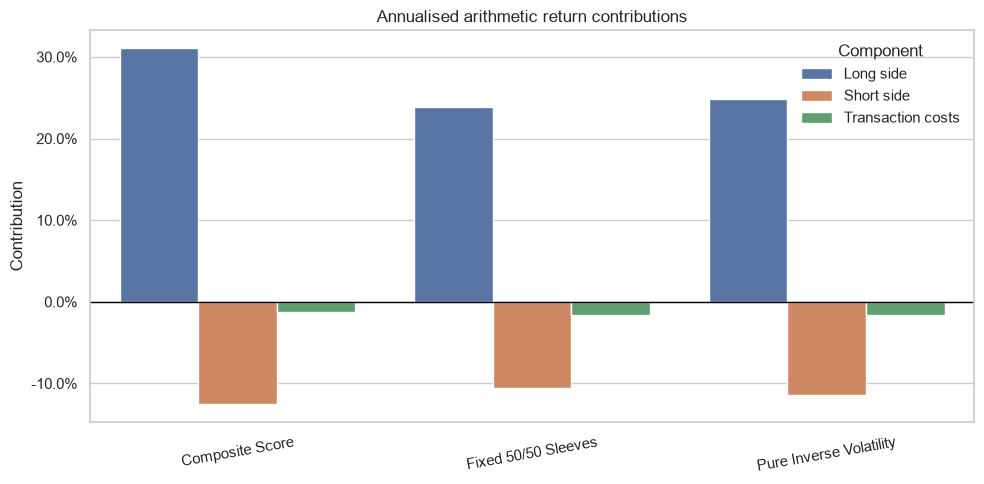

In [10]:
contribution_plot_data = (
    side_cost_attribution[
        [
            "annualised_long_contribution",
            "annualised_short_contribution",
            "annualised_cost_drag",
        ]
    ]
    .rename(
        columns={
            "annualised_long_contribution": ("Long side"),
            "annualised_short_contribution": ("Short side"),
            "annualised_cost_drag": ("Transaction costs"),
        }
    )
    .assign(**{"Transaction costs": lambda data: (-data["Transaction costs"])})
    .reset_index()
    .melt(
        id_vars="portfolio",
        var_name="component",
        value_name="annualised_contribution",
    )
)

fig, ax = plt.subplots(figsize=(10, 5))

sns.barplot(
    data=contribution_plot_data,
    x="portfolio",
    y="annualised_contribution",
    hue="component",
    ax=ax,
)

ax.axhline(
    0.0,
    color="black",
    linewidth=1.0,
)

ax.set_title("Annualised arithmetic return contributions")
ax.set_xlabel("")
ax.set_ylabel("Contribution")
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda value, _: f"{value:.1%}"))
ax.tick_params(
    axis="x",
    rotation=10,
)
ax.legend(
    title="Component",
    frameon=False,
)

plt.tight_layout()
plt.show()

#### Cumulative net performance and drawdowns

In [11]:
net_return_wide = portfolio_daily_analysis.pivot(
    index="date",
    columns="portfolio",
    values="net_return",
).reindex(columns=PORTFOLIO_ORDER)

net_return_wide["SPY"] = benchmark_daily.set_index("date")["benchmark_return"].reindex(
    net_return_wide.index
)

cumulative_wealth = (1.0 + net_return_wide).cumprod()

running_peak = cumulative_wealth.cummax().clip(lower=1.0)

drawdown_series = cumulative_wealth / running_peak - 1.0

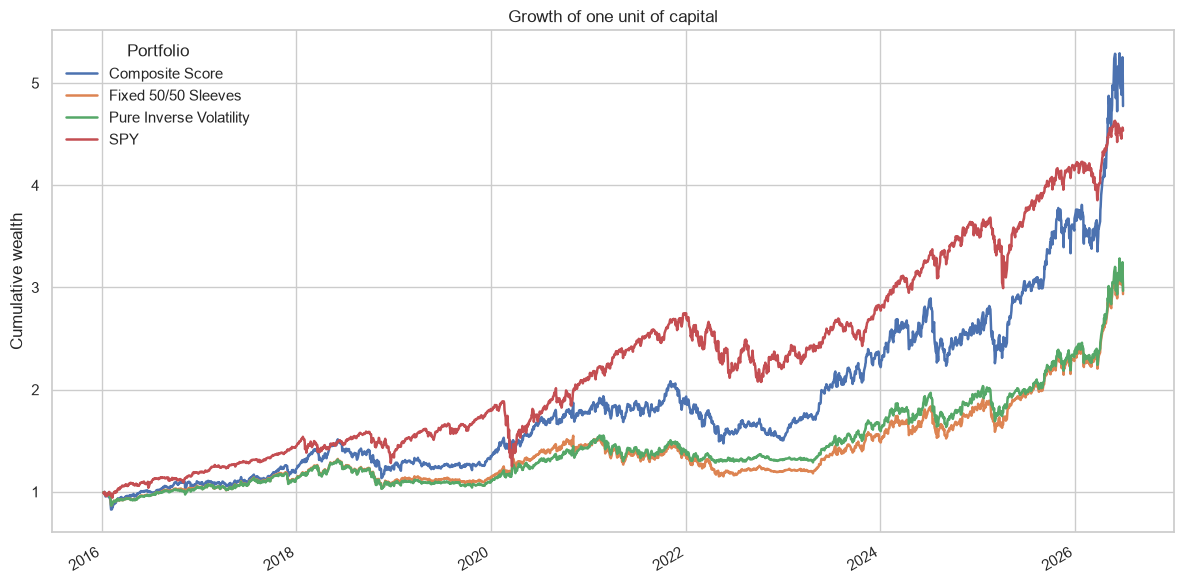

In [12]:
fig, ax = plt.subplots(figsize=(12, 6))

cumulative_wealth.plot(
    ax=ax,
    linewidth=1.8,
)

ax.set_title("Growth of one unit of capital")
ax.set_xlabel("")
ax.set_ylabel("Cumulative wealth")
ax.legend(
    title="Portfolio",
    frameon=False,
)

plt.tight_layout()
plt.show()

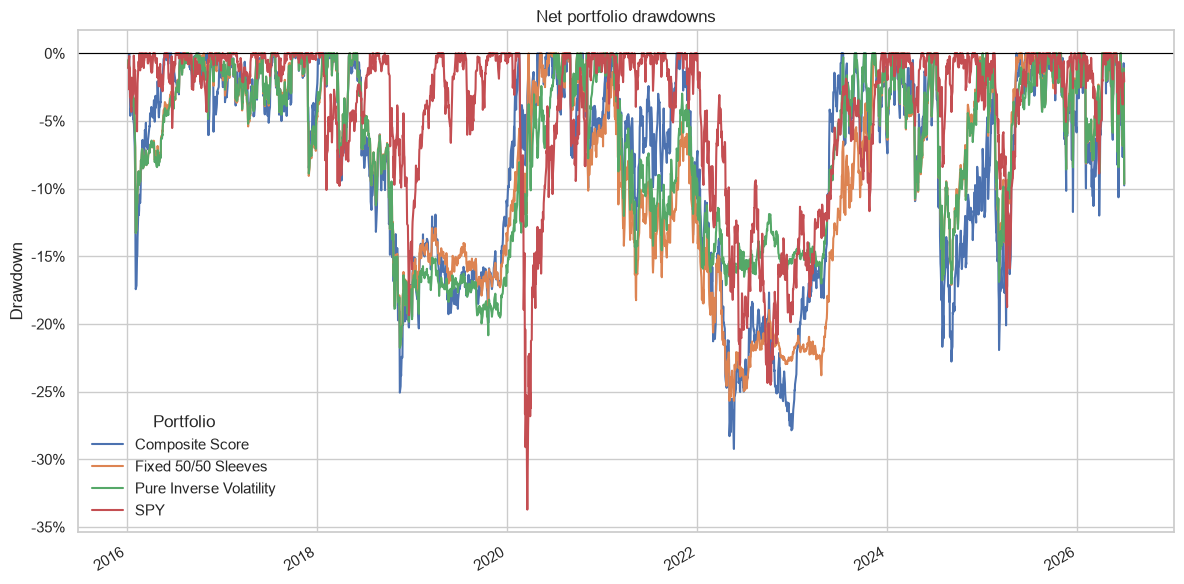

In [13]:
fig, ax = plt.subplots(figsize=(12, 6))

drawdown_series.plot(
    ax=ax,
    linewidth=1.5,
)

ax.axhline(
    0.0,
    color="black",
    linewidth=0.8,
)

ax.set_title("Net portfolio drawdowns")
ax.set_xlabel("")
ax.set_ylabel("Drawdown")
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda value, _: f"{value:.0%}"))
ax.legend(
    title="Portfolio",
    frameon=False,
)

plt.tight_layout()
plt.show()

## 3. Market exposure relative to SPY

For each portfolio return stream, the following market model is estimated:

$$
r_{p,t}=\alpha+\beta r_{\mathrm{SPY},t}+\varepsilon_t.
$$

Because the regression uses raw returns rather than excess returns, the intercept is reported as market-model alpha rather than formal CAPM alpha. Annualised active return and the information ratio describe performance relative to holding SPY, while beta, correlation and $R^2$ measure market exposure rather than outperformance.

#### Estimate market diagnostics

In [14]:
def calculate_market_diagnostics(
    portfolio_returns,
    market_returns,
):
    regression_data = pd.DataFrame(
        {
            "portfolio_return": (portfolio_returns),
            "market_return": (market_returns),
        }
    ).dropna()

    portfolio_values = regression_data["portfolio_return"].to_numpy()

    market_values = regression_data["market_return"].to_numpy()

    design_matrix = np.column_stack(
        [
            np.ones(len(regression_data)),
            market_values,
        ]
    )

    coefficients = np.linalg.lstsq(
        design_matrix,
        portfolio_values,
        rcond=None,
    )[0]

    daily_alpha = coefficients[0]
    beta = coefficients[1]

    fitted_returns = design_matrix @ coefficients
    residual_returns = portfolio_values - fitted_returns

    total_sum_of_squares = np.sum((portfolio_values - portfolio_values.mean()) ** 2)

    residual_sum_of_squares = np.sum(residual_returns**2)

    r_squared = (
        1.0 - residual_sum_of_squares / total_sum_of_squares
        if total_sum_of_squares > 0.0
        else np.nan
    )

    active_returns = portfolio_values - market_values

    active_volatility = np.std(
        active_returns,
        ddof=1,
    )

    information_ratio = (
        active_returns.mean() / active_volatility * np.sqrt(TRADING_DAYS_PER_YEAR)
        if not np.isclose(
            active_volatility,
            0.0,
        )
        else np.nan
    )

    return {
        "observations": len(regression_data),
        "annualised_market_model_alpha": (daily_alpha * TRADING_DAYS_PER_YEAR),
        "market_beta": beta,
        "market_correlation": (
            np.corrcoef(
                portfolio_values,
                market_values,
            )[0, 1]
        ),
        "r_squared": r_squared,
        "annualised_residual_volatility": (
            np.std(
                residual_returns,
                ddof=1,
            )
            * np.sqrt(TRADING_DAYS_PER_YEAR)
        ),
        "annualised_active_return": (active_returns.mean() * TRADING_DAYS_PER_YEAR),
        "annualised_tracking_error": (
            active_volatility * np.sqrt(TRADING_DAYS_PER_YEAR)
        ),
        "information_ratio": (information_ratio),
    }

In [15]:
market_exposure_rows = []

for portfolio_name in PORTFOLIO_ORDER:
    portfolio_data = portfolio_daily_analysis.loc[
        portfolio_daily_analysis["portfolio"].eq(portfolio_name)
    ].sort_values("date")

    for return_stream, return_column in RETURN_STREAMS.items():
        market_exposure_rows.append(
            {
                "portfolio": portfolio_name,
                "return_stream": return_stream,
                **calculate_market_diagnostics(
                    portfolio_returns=(portfolio_data[return_column]),
                    market_returns=(portfolio_data["benchmark_return"]),
                ),
            }
        )

market_exposure_summary = pd.DataFrame(market_exposure_rows)

market_exposure_summary["portfolio"] = pd.Categorical(
    market_exposure_summary["portfolio"],
    categories=PORTFOLIO_ORDER,
    ordered=True,
)

market_exposure_summary = market_exposure_summary.sort_values(
    [
        "portfolio",
        "return_stream",
    ]
).reset_index(drop=True)

display(
    market_exposure_summary.style.format(
        {
            "annualised_market_model_alpha": "{:.2%}",
            "market_beta": "{:.3f}",
            "market_correlation": "{:.3f}",
            "r_squared": "{:.3f}",
            "annualised_residual_volatility": "{:.2%}",
            "annualised_active_return": "{:.2%}",
            "annualised_tracking_error": "{:.2%}",
            "information_ratio": "{:.3f}",
        }
    )
)

,portfolio,return_stream,observations,annualised_market_model_alpha,market_beta,market_correlation,r_squared,annualised_residual_volatility,annualised_active_return,annualised_tracking_error,information_ratio
0,Composite Score,Gross,2635,8.67%,0.612,0.515,0.265,18.14%,2.43%,19.41%,0.125
1,Composite Score,Net,2635,7.38%,0.612,0.515,0.266,18.14%,1.15%,19.42%,0.059
2,Fixed 50/50 Sleeves,Gross,2635,6.01%,0.453,0.482,0.232,14.69%,-2.77%,17.63%,-0.157
3,Fixed 50/50 Sleeves,Net,2635,4.43%,0.453,0.482,0.232,14.69%,-4.35%,17.63%,-0.246
4,Pure Inverse Volatility,Gross,2635,7.23%,0.383,0.421,0.177,14.74%,-2.66%,18.39%,-0.145
5,Pure Inverse Volatility,Net,2635,5.57%,0.384,0.421,0.177,14.74%,-4.33%,18.39%,-0.235


### Interpretation

The **Composite Score** implementation delivers the strongest absolute performance among the selected portfolios. Its 16.13% net annualised return modestly exceeds SPY's 15.55%, and its maximum drawdown is smaller. However, this comes with higher volatility and a lower Sharpe ratio. The strategy therefore adds return and some drawdown protection, but does not outperform SPY consistently per unit of total risk.

The **Fixed 50/50** and **Pure Inverse Volatility** implementations are more defensive. Both have substantially lower market beta, volatility and maximum drawdown than SPY. Their lower absolute returns should therefore be interpreted partly as a consequence of reduced market exposure rather than simply weaker security selection.

All three portfolios have positive market-model alpha. Composite retains the highest net alpha at 7.38% annually. However, these values are economic point estimates rather than evidence of statistically significant alpha, and the regression uses raw rather than excess returns.

Return attribution shows that the long side generates the portfolios' average profits, while the short side detracts from average return. The short sleeve may nevertheless provide diversification and downside protection; its value should be reassessed during market sell-offs and major portfolio drawdowns rather than judged solely by its unconditional mean return.

Transaction costs reduce annual arithmetic return by approximately 1.3–1.7 percentage points. Composite incurs the lowest cost drag because its F21 implementation trades less frequently, although its average turnover on an individual rebalance date is higher.

> Overall, Composite is the strongest return-oriented specification, while Pure Inverse Volatility is the most defensive. None dominates SPY across return, volatility, drawdown and risk-adjusted performance simultaneously.

## 4. Rolling risk and market exposure

Full-sample statistics can conceal changes in portfolio behaviour across market regimes. This section estimates rolling six-month volatility, beta, correlation and tracking error using 126 trading-day windows.

Rolling estimates are calculated only after a complete window is available. They are descriptive diagnostics rather than independent observations or formal tests of parameter stability.

#### Calculate rolling diagnostics

In [16]:
ROLLING_RISK_WINDOW = 126

rolling_risk_parts = []

for portfolio_name in PORTFOLIO_ORDER:
    portfolio_data = (
        portfolio_daily_analysis.loc[
            portfolio_daily_analysis["portfolio"].eq(portfolio_name)
        ]
        .sort_values("date")
        .set_index("date")
    )

    portfolio_returns = portfolio_data["net_return"]

    market_returns = portfolio_data["benchmark_return"]

    rolling_market_variance = market_returns.rolling(
        window=ROLLING_RISK_WINDOW,
        min_periods=ROLLING_RISK_WINDOW,
    ).var()

    rolling_covariance = portfolio_returns.rolling(
        window=ROLLING_RISK_WINDOW,
        min_periods=ROLLING_RISK_WINDOW,
    ).cov(market_returns)

    rolling_risk_parts.append(
        pd.DataFrame(
            {
                "portfolio": portfolio_name,
                "annualised_volatility": (
                    portfolio_returns.rolling(
                        window=ROLLING_RISK_WINDOW,
                        min_periods=ROLLING_RISK_WINDOW,
                    ).std(ddof=1)
                    * np.sqrt(TRADING_DAYS_PER_YEAR)
                ),
                "market_beta": (rolling_covariance / rolling_market_variance),
                "market_correlation": (
                    portfolio_returns.rolling(
                        window=ROLLING_RISK_WINDOW,
                        min_periods=ROLLING_RISK_WINDOW,
                    ).corr(market_returns)
                ),
                "annualised_tracking_error": (
                    (portfolio_returns - market_returns)
                    .rolling(
                        window=ROLLING_RISK_WINDOW,
                        min_periods=ROLLING_RISK_WINDOW,
                    )
                    .std(ddof=1)
                    * np.sqrt(TRADING_DAYS_PER_YEAR)
                ),
            }
        ).reset_index()
    )

rolling_risk_diagnostics = (
    pd.concat(
        rolling_risk_parts,
        ignore_index=True,
    )
    .sort_values(
        [
            "portfolio",
            "date",
        ]
    )
    .reset_index(drop=True)
)

#### Summarise time variation

In [17]:
rolling_risk_summary = rolling_risk_diagnostics.groupby(
    "portfolio",
    sort=False,
).agg(
    rolling_observations=(
        "market_beta",
        "count",
    ),
    median_annualised_volatility=(
        "annualised_volatility",
        "median",
    ),
    maximum_annualised_volatility=(
        "annualised_volatility",
        "max",
    ),
    median_market_beta=(
        "market_beta",
        "median",
    ),
    tenth_pct_market_beta=(
        "market_beta",
        lambda values: values.quantile(0.10),
    ),
    ninetieth_pct_market_beta=(
        "market_beta",
        lambda values: values.quantile(0.90),
    ),
    median_market_correlation=(
        "market_correlation",
        "median",
    ),
    median_tracking_error=(
        "annualised_tracking_error",
        "median",
    ),
)

display(
    rolling_risk_summary.style.format(
        {
            "median_annualised_volatility": "{:.2%}",
            "maximum_annualised_volatility": "{:.2%}",
            "median_market_beta": "{:.3f}",
            "tenth_pct_market_beta": "{:.3f}",
            "ninetieth_pct_market_beta": "{:.3f}",
            "median_market_correlation": "{:.3f}",
            "median_tracking_error": "{:.2%}",
        }
    )
)

,rolling_observations,median_annualised_volatility,maximum_annualised_volatility,median_market_beta,tenth_pct_market_beta,ninetieth_pct_market_beta,median_market_correlation,median_tracking_error
portfolio,,,,,,,,
Composite Score,2510,19.78%,36.75%,0.732,0.267,1.450,0.576,17.14%
Fixed 50/50 Sleeves,2510,16.25%,30.10%,0.593,0.172,1.127,0.565,14.45%
Pure Inverse Volatility,2510,15.63%,30.18%,0.583,0.115,1.124,0.521,14.67%


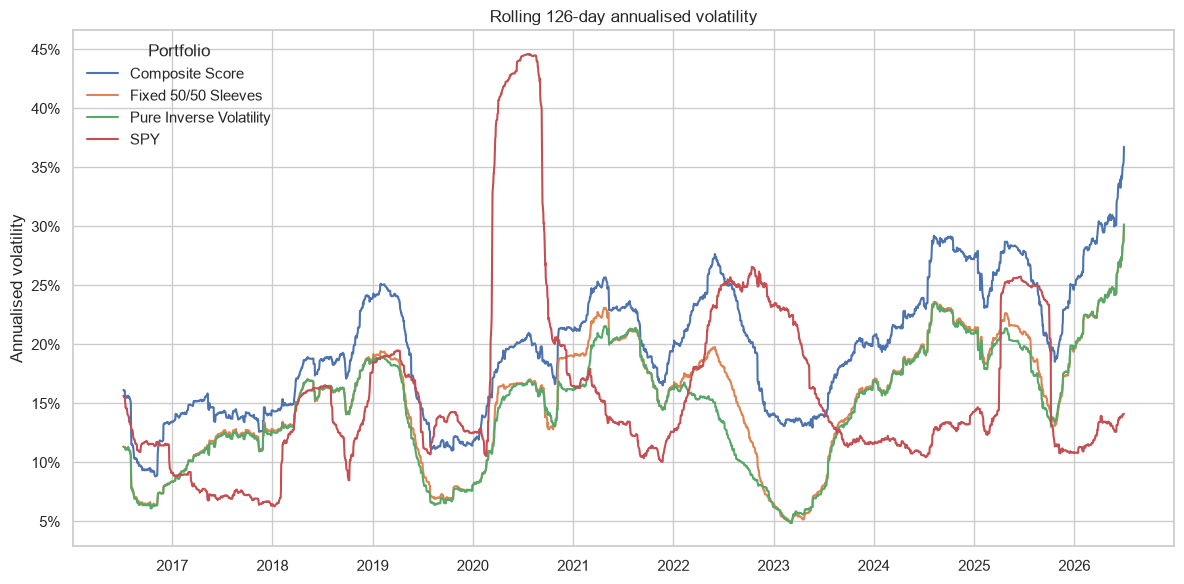

In [18]:
portfolio_volatility_plot_data = rolling_risk_diagnostics[
    [
        "date",
        "portfolio",
        "annualised_volatility",
    ]
].copy()

benchmark_volatility_plot_data = (
    benchmark_daily.sort_values("date")
    .set_index("date")["benchmark_return"]
    .rolling(
        window=ROLLING_RISK_WINDOW,
        min_periods=ROLLING_RISK_WINDOW,
    )
    .std(ddof=1)
    .mul(np.sqrt(TRADING_DAYS_PER_YEAR))
    .rename("annualised_volatility")
    .reset_index()
    .assign(portfolio="SPY")
)

volatility_plot_data = pd.concat(
    [
        portfolio_volatility_plot_data,
        benchmark_volatility_plot_data,
    ],
    ignore_index=True,
)

fig, ax = plt.subplots(figsize=(12, 6))

sns.lineplot(
    data=volatility_plot_data,
    x="date",
    y="annualised_volatility",
    hue="portfolio",
    ax=ax,
    linewidth=1.5,
)

ax.set_title("Rolling 126-day annualised volatility")
ax.set_xlabel("")
ax.set_ylabel("Annualised volatility")
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda value, _: f"{value:.0%}"))
ax.legend(
    title="Portfolio",
    frameon=False,
)

plt.tight_layout()
plt.show()

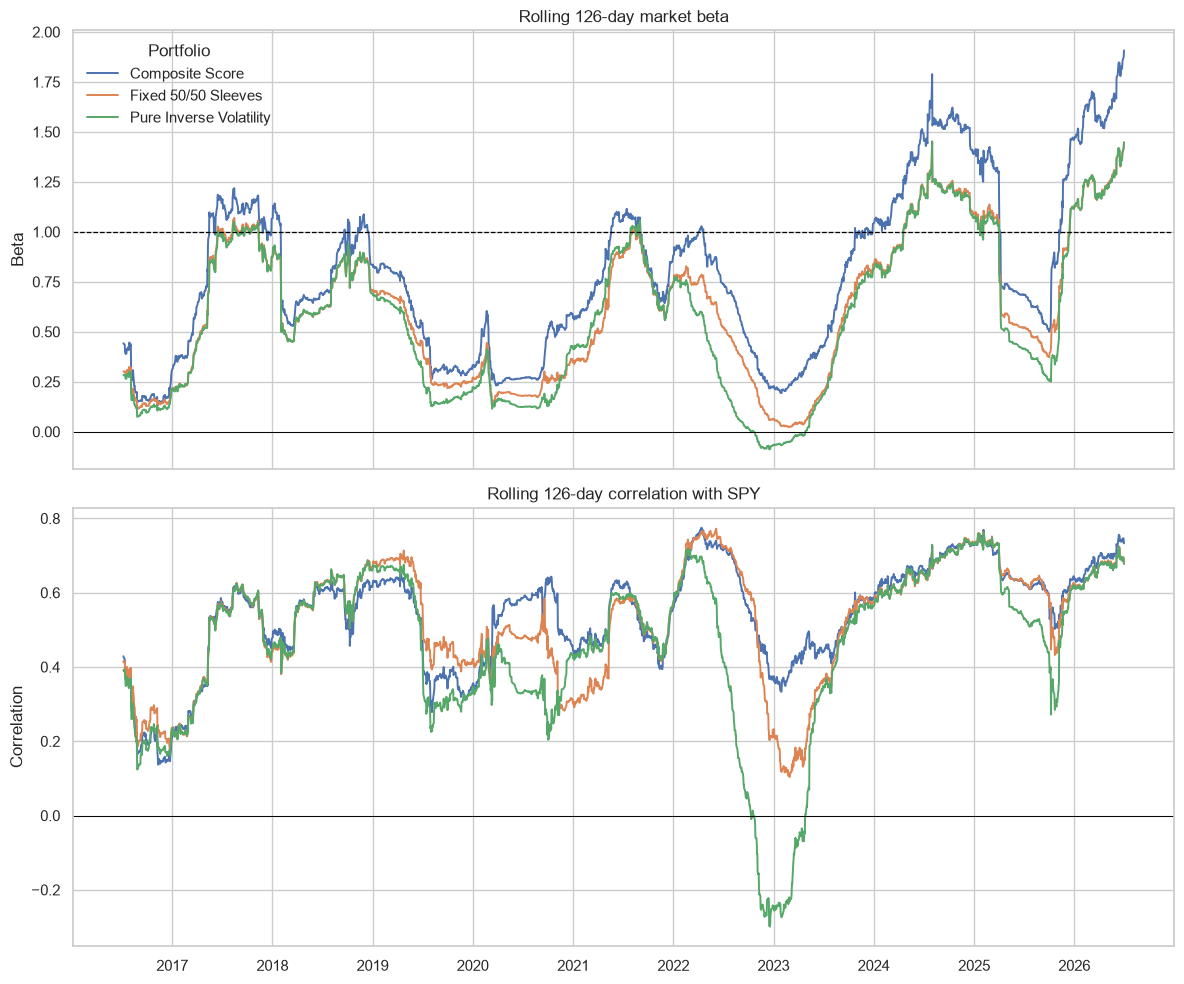

In [19]:
fig, axes = plt.subplots(
    nrows=2,
    ncols=1,
    figsize=(12, 10),
    sharex=True,
)

sns.lineplot(
    data=rolling_risk_diagnostics,
    x="date",
    y="market_beta",
    hue="portfolio",
    ax=axes[0],
    linewidth=1.4,
)

axes[0].axhline(
    1.0,
    color="black",
    linestyle="--",
    linewidth=0.9,
)
axes[0].axhline(
    0.0,
    color="black",
    linewidth=0.7,
)
axes[0].set_title("Rolling 126-day market beta")
axes[0].set_xlabel("")
axes[0].set_ylabel("Beta")
axes[0].legend(
    title="Portfolio",
    frameon=False,
)

sns.lineplot(
    data=rolling_risk_diagnostics,
    x="date",
    y="market_correlation",
    hue="portfolio",
    ax=axes[1],
    linewidth=1.4,
    legend=False,
)

axes[1].axhline(
    0.0,
    color="black",
    linewidth=0.7,
)
axes[1].set_title("Rolling 126-day correlation with SPY")
axes[1].set_xlabel("")
axes[1].set_ylabel("Correlation")

plt.tight_layout()
plt.show()


## 5. Exposure and concentration

This section examines how portfolio risk is distributed across securities.

Concentration is measured using absolute portfolio weights because the portfolios contain both long and short positions. The absolute-weight Herfindahl index is

$$
H_t=\sum_i\left(
\frac{|w_{i,t}|}{\sum_j |w_{j,t}|}
\right)^2,
$$

and the corresponding effective number of positions is $1/H_t$. It equals the actual number of positions when all absolute weights are equal and declines as the portfolio becomes more concentrated.

#### Construct daily diagnostics

In [20]:
WEIGHT_TOLERANCE = 1e-15

security_weight_diagnostics = security_daily.assign(
    absolute_weight=lambda data: (data["weight"].abs()),
    long_weight=lambda data: (data["weight"].clip(lower=0.0)),
    short_weight=lambda data: (-data["weight"].clip(upper=0.0)),
    squared_absolute_weight=lambda data: (data["weight"].abs().pow(2)),
)

security_exposure_daily = (
    security_weight_diagnostics.groupby(
        [
            "portfolio",
            "date",
        ],
        sort=True,
        observed=True,
    )
    .agg(
        gross_exposure=(
            "absolute_weight",
            "sum",
        ),
        net_exposure=(
            "weight",
            "sum",
        ),
        long_exposure=(
            "long_weight",
            "sum",
        ),
        short_exposure=(
            "short_weight",
            "sum",
        ),
        largest_absolute_weight=(
            "absolute_weight",
            "max",
        ),
        squared_weight_sum=(
            "squared_absolute_weight",
            "sum",
        ),
        held_position_count=(
            "absolute_weight",
            lambda values: (values.gt(WEIGHT_TOLERANCE).sum()),
        ),
    )
    .reset_index()
)

security_exposure_daily["absolute_weight_hhi"] = security_exposure_daily[
    "squared_weight_sum"
] / security_exposure_daily["gross_exposure"].pow(2)

security_exposure_daily["effective_position_count"] = (
    1.0 / security_exposure_daily["absolute_weight_hhi"]
)

security_exposure_daily["largest_position_gross_share"] = (
    security_exposure_daily["largest_absolute_weight"]
    / security_exposure_daily["gross_exposure"]
)

#### Reconcile exposure with the backtest output

In [21]:
exposure_reconciliation = portfolio_daily[
    [
        "portfolio",
        "date",
        "gross_exposure",
        "net_exposure",
        "long_exposure",
        "short_exposure",
    ]
].merge(
    security_exposure_daily[
        [
            "portfolio",
            "date",
            "gross_exposure",
            "net_exposure",
            "long_exposure",
            "short_exposure",
        ]
    ],
    on=[
        "portfolio",
        "date",
    ],
    how="inner",
    suffixes=(
        "_portfolio",
        "_security",
    ),
    validate="one_to_one",
)

exposure_audit_rows = []

for portfolio_name, portfolio_data in exposure_reconciliation.groupby(
    "portfolio",
    sort=False,
):
    audit_differences = {
        exposure_name: (
            portfolio_data[f"{exposure_name}_portfolio"]
            - portfolio_data[f"{exposure_name}_security"]
        )
        .abs()
        .max()
        for exposure_name in [
            "gross_exposure",
            "net_exposure",
            "long_exposure",
            "short_exposure",
        ]
    }

    maximum_difference = max(audit_differences.values())

    exposure_audit_rows.append(
        {
            "portfolio": portfolio_name,
            **{
                f"max_abs_{name}_difference": value
                for name, value in (audit_differences.items())
            },
            "maximum_absolute_difference": (maximum_difference),
            "audit_passes": (maximum_difference < ATTRIBUTION_TOLERANCE),
        }
    )

exposure_reconciliation_summary = pd.DataFrame(exposure_audit_rows).set_index(
    "portfolio"
)

display(exposure_reconciliation_summary)

if not exposure_reconciliation_summary["audit_passes"].all():
    raise ValueError("Security-level exposure " "reconciliation failed.")

,max_abs_gross_exposure_difference,max_abs_net_exposure_difference,max_abs_long_exposure_difference,max_abs_short_exposure_difference,maximum_absolute_difference,audit_passes
portfolio,,,,,,
Composite Score,4.440892e-16,4.440892e-16,2.220446e-16,4.440892e-16,4.440892e-16,True
Fixed 50/50 Sleeves,4.440892e-16,3.747003e-16,2.220446e-16,2.220446e-16,4.440892e-16,True
Pure Inverse Volatility,4.440892e-16,2.983724e-16,2.220446e-16,2.220446e-16,4.440892e-16,True


#### Summarise concentration

In [22]:
exposure_concentration_summary = security_exposure_daily.groupby(
    "portfolio",
    sort=False,
).agg(
    observations=("date", "size"),
    average_gross_exposure=(
        "gross_exposure",
        "mean",
    ),
    average_net_exposure=(
        "net_exposure",
        "mean",
    ),
    average_long_exposure=(
        "long_exposure",
        "mean",
    ),
    average_short_exposure=(
        "short_exposure",
        "mean",
    ),
    median_held_positions=(
        "held_position_count",
        "median",
    ),
    minimum_held_positions=(
        "held_position_count",
        "min",
    ),
    average_effective_positions=(
        "effective_position_count",
        "mean",
    ),
    minimum_effective_positions=(
        "effective_position_count",
        "min",
    ),
    average_largest_absolute_weight=(
        "largest_absolute_weight",
        "mean",
    ),
    maximum_largest_absolute_weight=(
        "largest_absolute_weight",
        "max",
    ),
    average_largest_position_share=(
        "largest_position_gross_share",
        "mean",
    ),
)

display(
    exposure_concentration_summary.style.format(
        {
            "average_gross_exposure": "{:.2f}",
            "average_net_exposure": "{:.2f}",
            "average_long_exposure": "{:.2f}",
            "average_short_exposure": "{:.2f}",
            "median_held_positions": "{:.0f}",
            "minimum_held_positions": "{:.0f}",
            "average_effective_positions": "{:.1f}",
            "minimum_effective_positions": "{:.1f}",
            "average_largest_absolute_weight": "{:.2%}",
            "maximum_largest_absolute_weight": "{:.2%}",
            "average_largest_position_share": "{:.2%}",
        }
    )
)

,observations,average_gross_exposure,average_net_exposure,average_long_exposure,average_short_exposure,median_held_positions,minimum_held_positions,average_effective_positions,minimum_effective_positions,average_largest_absolute_weight,maximum_largest_absolute_weight,average_largest_position_share
portfolio,,,,,,,,,,,,
Composite Score,2635,2.01,0.00,1.00,1.00,40,40,39.9,38.1,5.70%,8.87%,2.84%
Fixed 50/50 Sleeves,2635,1.54,0.00,0.77,0.77,53,26,47.1,25.9,5.25%,7.76%,3.51%
Pure Inverse Volatility,2635,1.61,0.00,0.81,0.80,61,40,49.7,27.0,5.26%,7.78%,3.34%


### Interpretation

All three portfolios are well diversified at the security level and remain approximately dollar-neutral. Composite consistently holds 40 securities and averages 39.9 effective positions, indicating nearly equal absolute weighting across its long and short books.

The sleeve portfolios hold more individual securities but have fewer effective positions than their raw position counts suggest. This reflects unequal weights and the partial netting of positions inherited from different sleeves. Pure Inverse Volatility holds more securities than Fixed 50/50, but increases the average effective position count only modestly.

Composite maintains approximately 100% long and 100% short exposure. The sleeve portfolios have lower gross exposure because overlapping sleeve positions can offset when combined. This lower realised exposure helps explain part of their lower volatility and market beta.

Rolling diagnostics show that risk exposure is not stable through time. Composite has the highest typical and maximum volatility, while Pure Inverse Volatility is marginally the least volatile. However, all three portfolios exhibit wide variation in rolling beta. Their upper-decile rolling betas exceed one, demonstrating that the low full-sample beta estimates do not represent persistent hedging relationships.

Overall, the portfolios are diversified across securities, but their market exposure remains regime-dependent. Pure Inverse Volatility is somewhat more defensive than Fixed 50/50, although the difference is not large enough to establish a clear diversification advantage.

## 6. Drawdown and stress-event attribution

The unconditional results show that the short sides detract from average return. However, a short sleeve can still be valuable if it generates positive contributions during severe market declines.

This section identifies the five largest SPY drawdown episodes in the common sample. For each episode, portfolio performance is measured from the first underwater day following the benchmark peak through the benchmark trough.

Portfolio net returns are compounded over each event. Long-, short- and cost-level results remain additive arithmetic contributions. The events are selected ex post and are therefore descriptive stress diagnostics rather than predictive tests.

#### Identify the largest SPY drawdown episodes

In [23]:
NUMBER_OF_STRESS_EVENTS = 5


def identify_drawdown_episodes(returns):
    returns = pd.Series(returns).dropna().sort_index()

    wealth = (1.0 + returns).cumprod()

    running_peak = wealth.cummax().clip(lower=1.0)

    drawdown = wealth / running_peak - 1.0
    underwater = drawdown.lt(0.0)

    episode_groups = underwater.ne(underwater.shift(fill_value=False)).cumsum()

    date_index = drawdown.index
    episode_rows = []

    for episode_id, episode_drawdown in drawdown.loc[underwater].groupby(
        episode_groups.loc[underwater]
    ):
        stress_start_date = episode_drawdown.index[0]
        last_underwater_date = episode_drawdown.index[-1]
        trough_date = episode_drawdown.idxmin()

        start_position = date_index.get_loc(stress_start_date)
        end_position = date_index.get_loc(last_underwater_date)

        peak_date = date_index[start_position - 1] if start_position > 0 else pd.NaT

        recovery_date = (
            date_index[end_position + 1]
            if end_position + 1 < len(date_index)
            else pd.NaT
        )

        episode_rows.append(
            {
                "episode_id": episode_id,
                "peak_date": peak_date,
                "stress_start_date": (stress_start_date),
                "trough_date": trough_date,
                "recovery_date": recovery_date,
                "benchmark_drawdown": (episode_drawdown.min()),
                "trading_days_to_trough": (
                    returns.loc[stress_start_date:trough_date].size
                ),
                "recovered_in_sample": (pd.notna(recovery_date)),
            }
        )

    return pd.DataFrame(episode_rows)

In [24]:
benchmark_return_series = benchmark_daily.sort_values("date").set_index("date")[
    "benchmark_return"
]

benchmark_drawdown_episodes = identify_drawdown_episodes(benchmark_return_series)

benchmark_stress_events = (
    benchmark_drawdown_episodes.nsmallest(
        NUMBER_OF_STRESS_EVENTS,
        "benchmark_drawdown",
    )
    .sort_values("trough_date")
    .reset_index(drop=True)
)

benchmark_stress_events["event_label"] = benchmark_stress_events.apply(
    lambda row: (
        f"{row['trough_date']:%Y-%m-%d} " f"({row['benchmark_drawdown']:.1%})"
    ),
    axis=1,
)

display(
    benchmark_stress_events.style.format(
        {
            "benchmark_drawdown": "{:.2%}",
        }
    )
)

,episode_id,peak_date,stress_start_date,trough_date,recovery_date,benchmark_drawdown,trading_days_to_trough,recovered_in_sample,event_label
0,129,2018-01-25 00:00:00,2018-01-26 00:00:00,2018-02-07 00:00:00,2018-08-03 00:00:00,-10.10%,9,True,2018-02-07 (-10.1%)
1,137,2018-09-19 00:00:00,2018-09-20 00:00:00,2018-12-21 00:00:00,2019-04-11 00:00:00,-19.35%,65,True,2018-12-21 (-19.3%)
2,187,2020-02-18 00:00:00,2020-02-19 00:00:00,2020-03-20 00:00:00,2020-08-07 00:00:00,-33.72%,23,True,2020-03-20 (-33.7%)
3,287,2021-12-31 00:00:00,2022-01-03 00:00:00,2022-10-11 00:00:00,2023-12-12 00:00:00,-24.50%,195,True,2022-10-11 (-24.5%)
4,353,2025-02-18 00:00:00,2025-02-19 00:00:00,2025-04-07 00:00:00,2025-06-25 00:00:00,-18.76%,34,True,2025-04-07 (-18.8%)


#### Attribute portfolio performance during stress events

In [25]:
def compound_period_return(returns):
    returns = pd.Series(returns).dropna()

    if returns.empty:
        return np.nan

    return (1.0 + returns).prod() - 1.0

In [26]:
stress_attribution_rows = []

for event in benchmark_stress_events.itertuples(index=False):
    for portfolio_name in PORTFOLIO_ORDER:
        event_data = portfolio_daily_analysis.loc[
            portfolio_daily_analysis["portfolio"].eq(portfolio_name)
            & portfolio_daily_analysis["date"].between(
                event.stress_start_date,
                event.trough_date,
            )
        ].sort_values("date")

        long_contribution = event_data["long_return"].sum()
        short_contribution = event_data["short_return"].sum()
        gross_contribution = event_data["gross_return"].sum()
        transaction_cost = event_data["transaction_cost"].sum()
        net_contribution = event_data["net_return"].sum()

        compounded_net_return = compound_period_return(event_data["net_return"])

        benchmark_return = compound_period_return(event_data["benchmark_return"])

        stress_attribution_rows.append(
            {
                "event_label": (event.event_label),
                "peak_date": event.peak_date,
                "stress_start_date": (event.stress_start_date),
                "trough_date": (event.trough_date),
                "benchmark_drawdown": (event.benchmark_drawdown),
                "portfolio": portfolio_name,
                "observations": len(event_data),
                "cumulative_long_contribution": (long_contribution),
                "cumulative_short_contribution": (short_contribution),
                "cumulative_gross_contribution": (gross_contribution),
                "cumulative_transaction_cost": (transaction_cost),
                "cumulative_net_contribution": (net_contribution),
                "compounded_net_return": (compounded_net_return),
                "net_minus_benchmark_return": (
                    compounded_net_return - benchmark_return
                ),
                "short_side_profitable": (short_contribution > 0.0),
                "outperformed_spy": (compounded_net_return > benchmark_return),
                "additive_reconciliation_difference": abs(
                    long_contribution
                    + short_contribution
                    - transaction_cost
                    - net_contribution
                ),
            }
        )

stress_attribution_detail = pd.DataFrame(stress_attribution_rows)

display(
    stress_attribution_detail.style.format(
        {
            "benchmark_drawdown": "{:.2%}",
            "cumulative_long_contribution": "{:.2%}",
            "cumulative_short_contribution": "{:.2%}",
            "cumulative_gross_contribution": "{:.2%}",
            "cumulative_transaction_cost": "{:.2%}",
            "cumulative_net_contribution": "{:.2%}",
            "compounded_net_return": "{:.2%}",
            "net_minus_benchmark_return": "{:.2%}",
            "additive_reconciliation_difference": ("{:.2e}"),
        }
    )
)

if (
    stress_attribution_detail["additive_reconciliation_difference"].max()
    >= ATTRIBUTION_TOLERANCE
):
    raise ValueError("Stress-event attribution does not " "reconcile.")

,event_label,peak_date,stress_start_date,trough_date,benchmark_drawdown,portfolio,observations,cumulative_long_contribution,cumulative_short_contribution,cumulative_gross_contribution,cumulative_transaction_cost,cumulative_net_contribution,compounded_net_return,net_minus_benchmark_return,short_side_profitable,outperformed_spy,additive_reconciliation_difference
0,2018-02-07 (-10.1%),2018-01-25 00:00:00,2018-01-26 00:00:00,2018-02-07 00:00:00,-10.10%,Composite Score,9,-10.35%,9.34%,-1.01%,0.09%,-1.10%,-1.18%,8.92%,True,True,8.67e-18
1,2018-02-07 (-10.1%),2018-01-25 00:00:00,2018-01-26 00:00:00,2018-02-07 00:00:00,-10.10%,Fixed 50/50 Sleeves,9,-9.69%,7.77%,-1.93%,0.09%,-2.02%,-2.05%,8.05%,True,True,6.94e-18
2,2018-02-07 (-10.1%),2018-01-25 00:00:00,2018-01-26 00:00:00,2018-02-07 00:00:00,-10.10%,Pure Inverse Volatility,9,-9.91%,7.98%,-1.93%,0.09%,-2.03%,-2.06%,8.04%,True,True,0.00e+00
3,2018-12-21 (-19.3%),2018-09-19 00:00:00,2018-09-20 00:00:00,2018-12-21 00:00:00,-19.35%,Composite Score,65,-26.49%,14.97%,-11.52%,0.32%,-11.84%,-12.12%,7.23%,True,True,5.55e-17
4,2018-12-21 (-19.3%),2018-09-19 00:00:00,2018-09-20 00:00:00,2018-12-21 00:00:00,-19.35%,Fixed 50/50 Sleeves,65,-20.90%,8.41%,-12.49%,0.52%,-13.01%,-12.78%,6.56%,True,True,2.78e-17
5,2018-12-21 (-19.3%),2018-09-19 00:00:00,2018-09-20 00:00:00,2018-12-21 00:00:00,-19.35%,Pure Inverse Volatility,65,-21.20%,8.63%,-12.57%,0.56%,-13.13%,-12.88%,6.47%,True,True,0.00e+00
6,2020-03-20 (-33.7%),2020-02-18 00:00:00,2020-02-19 00:00:00,2020-03-20 00:00:00,-33.72%,Composite Score,23,-38.29%,35.51%,-2.78%,0.12%,-2.90%,-3.19%,30.53%,True,True,3.47e-18
7,2020-03-20 (-33.7%),2020-02-18 00:00:00,2020-02-19 00:00:00,2020-03-20 00:00:00,-33.72%,Fixed 50/50 Sleeves,23,-29.45%,30.00%,0.55%,0.27%,0.29%,0.03%,33.75%,True,True,1.13e-17
8,2020-03-20 (-33.7%),2020-02-18 00:00:00,2020-02-19 00:00:00,2020-03-20 00:00:00,-33.72%,Pure Inverse Volatility,23,-30.76%,31.60%,0.84%,0.26%,0.58%,0.37%,34.08%,True,True,1.91e-17
9,2022-10-11 (-24.5%),2021-12-31 00:00:00,2022-01-03 00:00:00,2022-10-11 00:00:00,-24.50%,Composite Score,195,-28.69%,17.26%,-11.43%,1.20%,-12.63%,-13.54%,10.96%,True,True,2.78e-17


#### Summarise stress performance

In [27]:
stress_event_summary = stress_attribution_detail.groupby(
    "portfolio",
    sort=False,
).agg(
    event_count=(
        "event_label",
        "nunique",
    ),
    average_benchmark_drawdown=(
        "benchmark_drawdown",
        "mean",
    ),
    average_net_return=(
        "compounded_net_return",
        "mean",
    ),
    average_net_minus_benchmark_return=(
        "net_minus_benchmark_return",
        "mean",
    ),
    average_long_contribution=(
        "cumulative_long_contribution",
        "mean",
    ),
    average_short_contribution=(
        "cumulative_short_contribution",
        "mean",
    ),
    average_transaction_cost=(
        "cumulative_transaction_cost",
        "mean",
    ),
    short_profitable_event_fraction=(
        "short_side_profitable",
        "mean",
    ),
    spy_outperformance_fraction=(
        "outperformed_spy",
        "mean",
    ),
    worst_event_net_return=(
        "compounded_net_return",
        "min",
    ),
)

display(
    stress_event_summary.style.format(
        {
            "average_benchmark_drawdown": "{:.2%}",
            "average_net_return": "{:.2%}",
            "average_net_minus_benchmark_return": "{:.2%}",
            "average_long_contribution": "{:.2%}",
            "average_short_contribution": "{:.2%}",
            "average_transaction_cost": "{:.2%}",
            "short_profitable_event_fraction": "{:.0%}",
            "spy_outperformance_fraction": "{:.0%}",
            "worst_event_net_return": "{:.2%}",
        }
    )
)

,event_count,average_benchmark_drawdown,average_net_return,average_net_minus_benchmark_return,average_long_contribution,average_short_contribution,average_transaction_cost,short_profitable_event_fraction,spy_outperformance_fraction,worst_event_net_return
portfolio,,,,,,,,,,
Composite Score,5,-21.28%,-8.81%,12.48%,-25.86%,17.69%,0.37%,100%,100%,-14.01%
Fixed 50/50 Sleeves,5,-21.28%,-7.23%,14.05%,-20.29%,13.56%,0.45%,100%,100%,-12.78%
Pure Inverse Volatility,5,-21.28%,-5.77%,15.52%,-20.57%,15.36%,0.51%,100%,100%,-12.88%


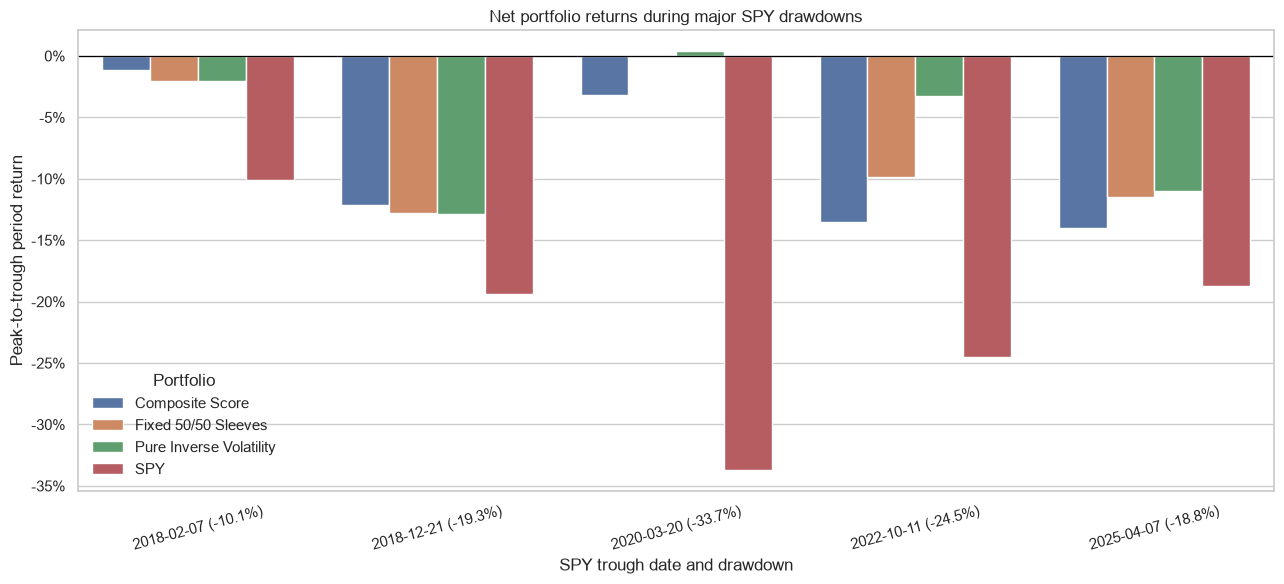

In [28]:
EVENT_ORDER = benchmark_stress_events["event_label"].tolist()

stress_return_plot_data = pd.concat(
    [
        stress_attribution_detail[
            [
                "event_label",
                "portfolio",
                "compounded_net_return",
            ]
        ].rename(
            columns={
                "portfolio": "strategy",
                "compounded_net_return": ("period_return"),
            }
        ),
        benchmark_stress_events[
            [
                "event_label",
                "benchmark_drawdown",
            ]
        ]
        .rename(
            columns={
                "benchmark_drawdown": ("period_return"),
            }
        )
        .assign(strategy="SPY"),
    ],
    ignore_index=True,
)

fig, ax = plt.subplots(figsize=(13, 6))

sns.barplot(
    data=stress_return_plot_data,
    x="event_label",
    y="period_return",
    hue="strategy",
    order=EVENT_ORDER,
    hue_order=[
        *PORTFOLIO_ORDER,
        "SPY",
    ],
    errorbar=None,
    ax=ax,
)

ax.axhline(
    0.0,
    color="black",
    linewidth=0.9,
)

ax.set_title("Net portfolio returns during major SPY drawdowns")
ax.set_xlabel("SPY trough date and drawdown")
ax.set_ylabel("Peak-to-trough period return")
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda value, _: f"{value:.0%}"))
ax.tick_params(
    axis="x",
    rotation=15,
)
ax.legend(
    title="Portfolio",
    frameon=False,
)

plt.tight_layout()
plt.show()

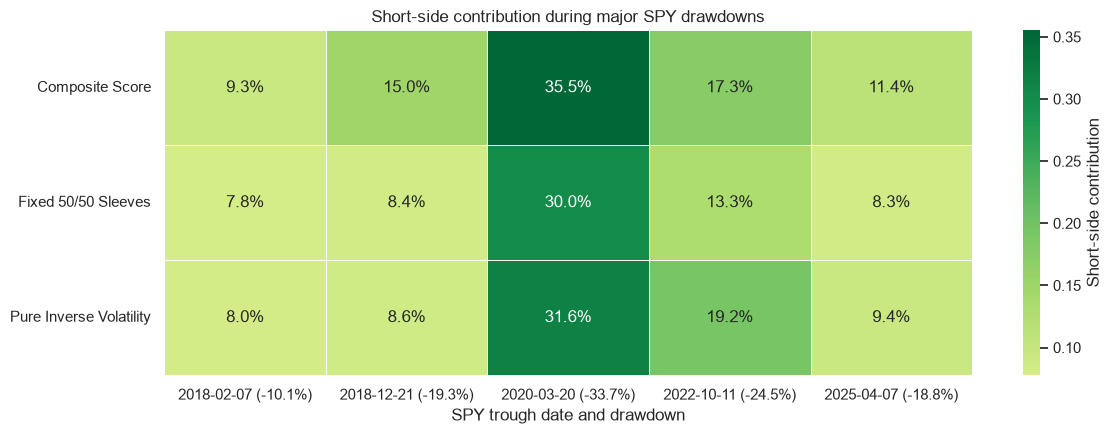

In [29]:
short_contribution_matrix = stress_attribution_detail.pivot(
    index="portfolio",
    columns="event_label",
    values="cumulative_short_contribution",
).reindex(
    index=PORTFOLIO_ORDER,
    columns=EVENT_ORDER,
)

fig, ax = plt.subplots(figsize=(12, 4.5))

sns.heatmap(
    short_contribution_matrix,
    annot=True,
    fmt=".1%",
    cmap="RdYlGn",
    center=0.0,
    linewidths=0.5,
    cbar_kws={"label": "Short-side contribution"},
    ax=ax,
)

ax.set_title("Short-side contribution during major SPY drawdowns")
ax.set_xlabel("SPY trough date and drawdown")
ax.set_ylabel("")

plt.tight_layout()
plt.show()

### Interpretation

The short sleeves provide consistent downside protection during the five largest SPY drawdowns in the sample. Short-side contributions are positive for every portfolio in every event, and all three portfolios outperform SPY in all five episodes.

Pure Inverse Volatility provides the strongest average stress protection. It loses 5.77% during an average SPY drawdown of 21.28%, outperforming the benchmark by 15.52 percentage points. Its strongest relative result occurs during the 2022 decline, when a 19.17% short-side contribution helps limit the portfolio loss to 3.22%.

The 2020 crash provides the clearest example of effective long-short diversification. Although the long books lose approximately 29–38%, the short books offset most or all of those losses. Fixed 50/50 is approximately flat, while Pure Inverse Volatility earns a small positive return despite the 33.72% SPY drawdown.

Nevertheless, downside protection is not equivalent to absolute capital preservation. Most portfolio-event returns remain negative, and all three strategies suffer double-digit losses during some events. The short sleeves therefore mitigate rather than eliminate market stress.

These results also do not establish that the selected short securities provide superior protection to a passive market hedge. Because the portfolios hold substantial short exposure, positive short contributions are mechanically expected when the market falls. The next diagnostic compares each short sleeve with a same-notional short-SPY position.

## 7. Short-side hedge efficiency

Positive short-side returns during market declines do not necessarily demonstrate successful short-security selection. A passive short-SPY position would also generate positive returns in those periods.

For each portfolio, the passive hedge contribution is approximated by

$$
r^{\mathrm{passive\ short}}_t
=
-s_t r_{\mathrm{SPY},t},
$$

where $s_t$ is the portfolio's absolute short exposure. The difference

$$
r^{\mathrm{short\ excess}}_t
=
r^{\mathrm{actual\ short}}_t
-
r^{\mathrm{passive\ short}}_t
$$

measures the short sleeve's performance relative to a same-notional short-SPY hedge.

This is a diagnostic benchmark rather than a complete factor-adjusted attribution. The difference can reflect security selection, sector exposures, security betas and other style characteristics.

#### Construct the passive hedge comparator

In [30]:
short_hedge_daily = portfolio_daily_analysis.assign(
    passive_short_spy_contribution=lambda data: (
        -data["short_exposure"] * data["benchmark_return"]
    )
)

short_hedge_daily["short_excess_vs_passive"] = (
    short_hedge_daily["short_return"]
    - short_hedge_daily["passive_short_spy_contribution"]
)

#### Full-sample comparison

In [31]:
short_hedge_summary_rows = []

for portfolio_name, portfolio_data in short_hedge_daily.groupby(
    "portfolio",
    sort=False,
):
    actual_short = portfolio_data["short_return"]

    passive_short = portfolio_data["passive_short_spy_contribution"]

    short_excess = portfolio_data["short_excess_vs_passive"]

    short_hedge_summary_rows.append(
        {
            "portfolio": portfolio_name,
            "observations": len(portfolio_data),
            "average_short_exposure": (portfolio_data["short_exposure"].mean()),
            "cumulative_actual_short_contribution": (actual_short.sum()),
            "cumulative_passive_short_contribution": (passive_short.sum()),
            "cumulative_short_excess_vs_passive": (short_excess.sum()),
            "annualised_actual_short_contribution": (
                actual_short.mean() * TRADING_DAYS_PER_YEAR
            ),
            "annualised_passive_short_contribution": (
                passive_short.mean() * TRADING_DAYS_PER_YEAR
            ),
            "annualised_short_excess_vs_passive": (
                short_excess.mean() * TRADING_DAYS_PER_YEAR
            ),
            "actual_short_profitable_day_fraction": (actual_short.gt(0.0).mean()),
            "short_excess_positive_day_fraction": (short_excess.gt(0.0).mean()),
            "actual_passive_correlation": (actual_short.corr(passive_short)),
        }
    )

short_hedge_summary = (
    pd.DataFrame(short_hedge_summary_rows)
    .set_index("portfolio")
    .reindex(PORTFOLIO_ORDER)
)

display(
    short_hedge_summary.style.format(
        {
            "average_short_exposure": "{:.2f}",
            "cumulative_actual_short_contribution": "{:.2%}",
            "cumulative_passive_short_contribution": "{:.2%}",
            "cumulative_short_excess_vs_passive": "{:.2%}",
            "annualised_actual_short_contribution": "{:.2%}",
            "annualised_passive_short_contribution": "{:.2%}",
            "annualised_short_excess_vs_passive": "{:.2%}",
            "actual_short_profitable_day_fraction": "{:.2%}",
            "short_excess_positive_day_fraction": "{:.2%}",
            "actual_passive_correlation": "{:.3f}",
        }
    )
)

,observations,average_short_exposure,cumulative_actual_short_contribution,cumulative_passive_short_contribution,cumulative_short_excess_vs_passive,annualised_actual_short_contribution,annualised_passive_short_contribution,annualised_short_excess_vs_passive,actual_short_profitable_day_fraction,short_excess_positive_day_fraction,actual_passive_correlation
portfolio,,,,,,,,,,,
Composite Score,2635,1.00,-131.42%,-160.94%,29.52%,-12.57%,-15.39%,2.82%,45.69%,52.56%,0.792
Fixed 50/50 Sleeves,2635,0.77,-110.37%,-127.23%,16.86%,-10.56%,-12.17%,1.61%,45.09%,52.83%,0.802
Pure Inverse Volatility,2635,0.80,-119.61%,-134.59%,14.98%,-11.44%,-12.87%,1.43%,45.12%,52.87%,0.835


#### Comparison during the five stress events

In [32]:
short_hedge_stress_rows = []

for event in benchmark_stress_events.itertuples(index=False):
    for portfolio_name in PORTFOLIO_ORDER:
        event_data = short_hedge_daily.loc[
            short_hedge_daily["portfolio"].eq(portfolio_name)
            & short_hedge_daily["date"].between(
                event.stress_start_date,
                event.trough_date,
            )
        ].sort_values("date")

        actual_short_contribution = event_data["short_return"].sum()

        passive_short_contribution = event_data["passive_short_spy_contribution"].sum()

        short_excess_vs_passive = actual_short_contribution - passive_short_contribution

        hedge_efficiency_ratio = (
            actual_short_contribution / passive_short_contribution
            if passive_short_contribution > 0.0
            else np.nan
        )

        short_hedge_stress_rows.append(
            {
                "event_label": event.event_label,
                "portfolio": portfolio_name,
                "observations": len(event_data),
                "average_short_exposure": (event_data["short_exposure"].mean()),
                "actual_short_contribution": (actual_short_contribution),
                "passive_short_spy_contribution": (passive_short_contribution),
                "short_excess_vs_passive": (short_excess_vs_passive),
                "hedge_efficiency_ratio": (hedge_efficiency_ratio),
                "actual_short_outperformed_passive": (short_excess_vs_passive > 0.0),
            }
        )

short_hedge_stress_detail = pd.DataFrame(short_hedge_stress_rows)

display(
    short_hedge_stress_detail.style.format(
        {
            "average_short_exposure": "{:.2f}",
            "actual_short_contribution": "{:.2%}",
            "passive_short_spy_contribution": "{:.2%}",
            "short_excess_vs_passive": "{:.2%}",
            "hedge_efficiency_ratio": "{:.2f}",
        }
    )
)

,event_label,portfolio,observations,average_short_exposure,actual_short_contribution,passive_short_spy_contribution,short_excess_vs_passive,hedge_efficiency_ratio,actual_short_outperformed_passive
0,2018-02-07 (-10.1%),Composite Score,9,0.96,9.34%,10.09%,-0.75%,0.93,False
1,2018-02-07 (-10.1%),Fixed 50/50 Sleeves,9,0.81,7.77%,8.68%,-0.91%,0.90,False
2,2018-02-07 (-10.1%),Pure Inverse Volatility,9,0.83,7.98%,8.85%,-0.87%,0.90,False
3,2018-12-21 (-19.3%),Composite Score,65,1.04,14.97%,20.04%,-5.07%,0.75,False
4,2018-12-21 (-19.3%),Fixed 50/50 Sleeves,65,0.80,8.41%,16.20%,-7.79%,0.52,False
5,2018-12-21 (-19.3%),Pure Inverse Volatility,65,0.82,8.63%,16.76%,-8.13%,0.51,False
6,2020-03-20 (-33.7%),Composite Score,23,0.91,35.51%,36.41%,-0.90%,0.98,False
7,2020-03-20 (-33.7%),Fixed 50/50 Sleeves,23,0.75,30.00%,30.46%,-0.46%,0.98,False
8,2020-03-20 (-33.7%),Pure Inverse Volatility,23,0.78,31.60%,31.61%,-0.02%,1.00,False
9,2022-10-11 (-24.5%),Composite Score,195,1.00,17.26%,26.85%,-9.59%,0.64,False


In [36]:
short_hedge_stress_summary = (
    short_hedge_stress_detail.groupby(
        "portfolio",
        sort=False,
    )
    .agg(
        event_count=(
            "event_label",
            "nunique",
        ),
        average_actual_short_contribution=(
            "actual_short_contribution",
            "mean",
        ),
        average_passive_short_contribution=(
            "passive_short_spy_contribution",
            "mean",
        ),
        average_short_excess_vs_passive=(
            "short_excess_vs_passive",
            "mean",
        ),
        median_hedge_efficiency_ratio=(
            "hedge_efficiency_ratio",
            "median",
        ),
        actual_outperformance_fraction=(
            "actual_short_outperformed_passive",
            "mean",
        ),
        minimum_short_excess_vs_passive=(
            "short_excess_vs_passive",
            "min",
        ),
    )
    .reindex(PORTFOLIO_ORDER)
)

display(
    short_hedge_stress_summary.style.format(
        {
            "average_actual_short_contribution": "{:.2%}",
            "average_passive_short_contribution": "{:.2%}",
            "average_short_excess_vs_passive": "{:.2%}",
            "median_hedge_efficiency_ratio": "{:.2f}",
            "actual_outperformance_fraction": "{:.0%}",
            "minimum_short_excess_vs_passive": "{:.2%}",
        }
    )
)

,event_count,average_actual_short_contribution,average_passive_short_contribution,average_short_excess_vs_passive,median_hedge_efficiency_ratio,actual_outperformance_fraction,minimum_short_excess_vs_passive
portfolio,,,,,,,
Composite Score,5,17.69%,22.95%,-5.25%,0.75,0%,-9.96%
Fixed 50/50 Sleeves,5,13.56%,17.90%,-4.34%,0.75,0%,-8.10%
Pure Inverse Volatility,5,15.36%,18.76%,-3.39%,0.90,0%,-8.13%


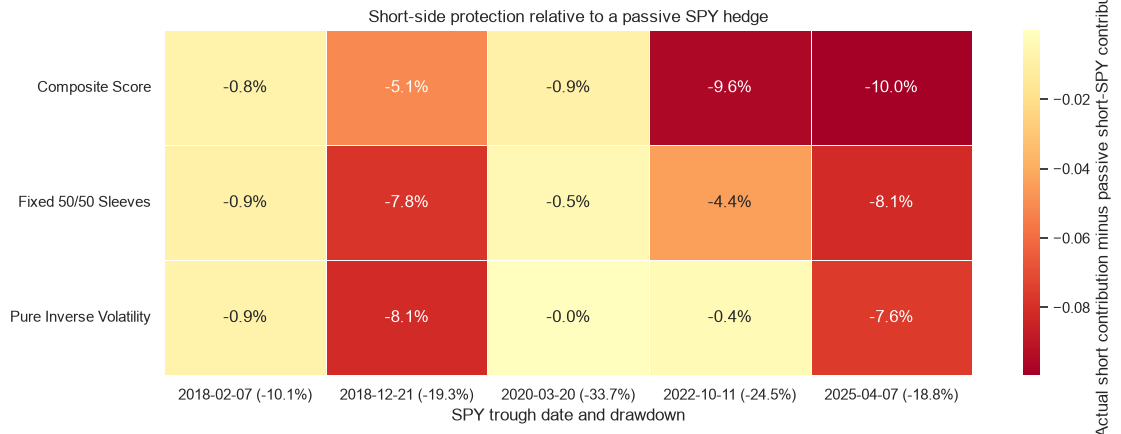

In [34]:
short_excess_matrix = short_hedge_stress_detail.pivot(
    index="portfolio",
    columns="event_label",
    values="short_excess_vs_passive",
).reindex(
    index=PORTFOLIO_ORDER,
    columns=EVENT_ORDER,
)

fig, ax = plt.subplots(figsize=(12, 4.5))

sns.heatmap(
    short_excess_matrix,
    annot=True,
    fmt=".1%",
    cmap="RdYlGn",
    center=0.0,
    linewidths=0.5,
    cbar_kws={
        "label": ("Actual short contribution " "minus passive short-SPY contribution")
    },
    ax=ax,
)

ax.set_title("Short-side protection relative to a passive SPY hedge")
ax.set_xlabel("SPY trough date and drawdown")
ax.set_ylabel("")

plt.tight_layout()
plt.show()

### Interpretation

The security-selected short books outperform same-notional short-SPY positions over the full sample. Their annualised excess contributions range from 1.43% to 2.82%, and their excess contributions are positive on approximately 53% of trading days. Composite records the strongest full-sample relative performance.

However, passive short SPY provides greater protection in every one of the five major drawdown events. The selected short books therefore appear to have less downside market sensitivity than SPY. This is beneficial during ordinary rising markets, because the short books lose less than a direct market short, but it limits their gains during severe market declines.

Pure Inverse Volatility offers the strongest stress-event hedge efficiency. Its median ratio of actual to passive protection is 0.90, and it nearly matches passive short SPY during the 2020 and 2022 declines. Nevertheless, its protection remains regime-dependent, with substantially lower efficiency during late 2018 and early 2025.

Overall, the short-security selection exhibits a trade-off between average relative performance and crisis protection. It adds value relative to passive short SPY across the full sample and still materially offsets long-side losses during stress, but it should not be interpreted as a substitute for a direct market hedge.

The cumulative contribution statistics are arithmetic attribution measures rather than compounded standalone short-portfolio returns. Furthermore, excess performance relative to SPY can reflect differences in market beta, sector exposure and style characteristics as well as security selection.

## 8. Conditional short-side hedge behaviour

The full-sample and stress-event results indicate a trade-off between average relative performance and crisis protection. This section tests that relationship systematically across the distribution of daily SPY returns.

Trading days are divided into five regimes using full-sample SPY-return quantiles:

- bottom 5%;
- 5th–20th percentile;
- middle 60%;
- 80th–95th percentile;
- top 5%.

For each regime, the analysis compares the actual short-side contribution with a same-notional passive short-SPY contribution. Average daily contributions are reported in basis points, while cumulative short excess measures each regime's total contribution to the full-sample result.

Because the regimes are defined ex post using full-sample quantiles, this is a descriptive conditional diagnostic rather than a real-time trading rule.

#### Define market-return regimes

In [37]:
MARKET_REGIME_ORDER = [
    "Bottom 5%",
    "5th–20th percentile",
    "Middle 60%",
    "80th–95th percentile",
    "Top 5%",
]

benchmark_regime_daily = (
    short_hedge_daily[
        [
            "date",
            "benchmark_return",
        ]
    ]
    .drop_duplicates()
    .sort_values("date")
    .reset_index(drop=True)
)

benchmark_return_count_by_date = short_hedge_daily.groupby("date")[
    "benchmark_return"
].nunique()

if benchmark_return_count_by_date.max() != 1:
    raise ValueError("Multiple benchmark returns found " "for the same date.")

market_regime_quantiles = benchmark_regime_daily["benchmark_return"].quantile(
    [
        0.05,
        0.20,
        0.80,
        0.95,
    ]
)

market_regime_thresholds = (
    market_regime_quantiles.rename(
        index={
            0.05: "5th percentile",
            0.20: "20th percentile",
            0.80: "80th percentile",
            0.95: "95th percentile",
        }
    )
    .rename("SPY return threshold")
    .to_frame()
)

display(market_regime_thresholds.style.format("{:.2%}"))

,SPY return threshold
5th percentile,-1.67%
20th percentile,-0.53%
80th percentile,0.75%
95th percentile,1.56%


In [38]:
market_regime_edges = [
    -np.inf,
    market_regime_quantiles.loc[0.05],
    market_regime_quantiles.loc[0.20],
    market_regime_quantiles.loc[0.80],
    market_regime_quantiles.loc[0.95],
    np.inf,
]

benchmark_regime_daily["market_regime"] = pd.cut(
    benchmark_regime_daily["benchmark_return"],
    bins=market_regime_edges,
    labels=MARKET_REGIME_ORDER,
    include_lowest=True,
    ordered=True,
)

conditional_short_hedge_daily = short_hedge_daily.drop(
    columns="market_regime",
    errors="ignore",
).merge(
    benchmark_regime_daily[
        [
            "date",
            "market_regime",
        ]
    ],
    on="date",
    how="left",
    validate="many_to_one",
)

if conditional_short_hedge_daily["market_regime"].isna().any():
    raise ValueError("Some observations were not assigned " "to a market regime.")

#### Summarise conditional hedge performance

In [39]:
conditional_short_hedge_summary = (
    conditional_short_hedge_daily.groupby(
        [
            "portfolio",
            "market_regime",
        ],
        observed=True,
        sort=False,
    )
    .agg(
        observations=(
            "date",
            "size",
        ),
        average_spy_return=(
            "benchmark_return",
            "mean",
        ),
        average_actual_short_contribution=(
            "short_return",
            "mean",
        ),
        average_passive_short_contribution=(
            "passive_short_spy_contribution",
            "mean",
        ),
        average_short_excess_vs_passive=(
            "short_excess_vs_passive",
            "mean",
        ),
        cumulative_short_excess_vs_passive=(
            "short_excess_vs_passive",
            "sum",
        ),
        actual_short_profitable_day_fraction=(
            "short_return",
            lambda values: values.gt(0.0).mean(),
        ),
        short_excess_positive_day_fraction=(
            "short_excess_vs_passive",
            lambda values: values.gt(0.0).mean(),
        ),
    )
    .reindex(
        pd.MultiIndex.from_product(
            [
                PORTFOLIO_ORDER,
                MARKET_REGIME_ORDER,
            ],
            names=[
                "portfolio",
                "market_regime",
            ],
        )
    )
)

In [40]:
basis_point_columns = [
    "average_actual_short_contribution",
    "average_passive_short_contribution",
    "average_short_excess_vs_passive",
]

conditional_summary_display = conditional_short_hedge_summary.copy()

conditional_summary_display[basis_point_columns] = (
    conditional_summary_display[basis_point_columns] * 10_000
)

display(
    conditional_summary_display.style.format(
        {
            "average_spy_return": "{:.2%}",
            "average_actual_short_contribution": ("{:.2f} bps"),
            "average_passive_short_contribution": ("{:.2f} bps"),
            "average_short_excess_vs_passive": ("{:.2f} bps"),
            "cumulative_short_excess_vs_passive": ("{:.2%}"),
            "actual_short_profitable_day_fraction": ("{:.1%}"),
            "short_excess_positive_day_fraction": ("{:.1%}"),
        }
    )
)

#### Reconcile conditional and full-sample results

In [41]:
conditional_short_excess_audit = (
    conditional_short_hedge_summary.groupby(level="portfolio")[
        "cumulative_short_excess_vs_passive"
    ]
    .sum()
    .rename("conditional_cumulative_short_excess")
    .to_frame()
    .join(
        short_hedge_summary[
            [
                "cumulative_short_excess_vs_passive",
            ]
        ].rename(
            columns={
                "cumulative_short_excess_vs_passive": (
                    "full_sample_cumulative_short_excess"
                )
            }
        )
    )
)

conditional_short_excess_audit["absolute_difference"] = (
    conditional_short_excess_audit["conditional_cumulative_short_excess"]
    - conditional_short_excess_audit["full_sample_cumulative_short_excess"]
).abs()

conditional_short_excess_audit["audit_passes"] = (
    conditional_short_excess_audit["absolute_difference"] < ATTRIBUTION_TOLERANCE
)

display(conditional_short_excess_audit)

if not conditional_short_excess_audit["audit_passes"].all():
    raise ValueError("Conditional short-side attribution " "does not reconcile.")

,conditional_cumulative_short_excess,full_sample_cumulative_short_excess,absolute_difference,audit_passes
portfolio,,,,
Composite Score,0.295217,0.295217,1.110223e-16,True
Fixed 50/50 Sleeves,0.168604,0.168604,1.665335e-16,True
Pure Inverse Volatility,0.149810,0.149810,2.220446e-16,True


#### Visualise conditional short excess

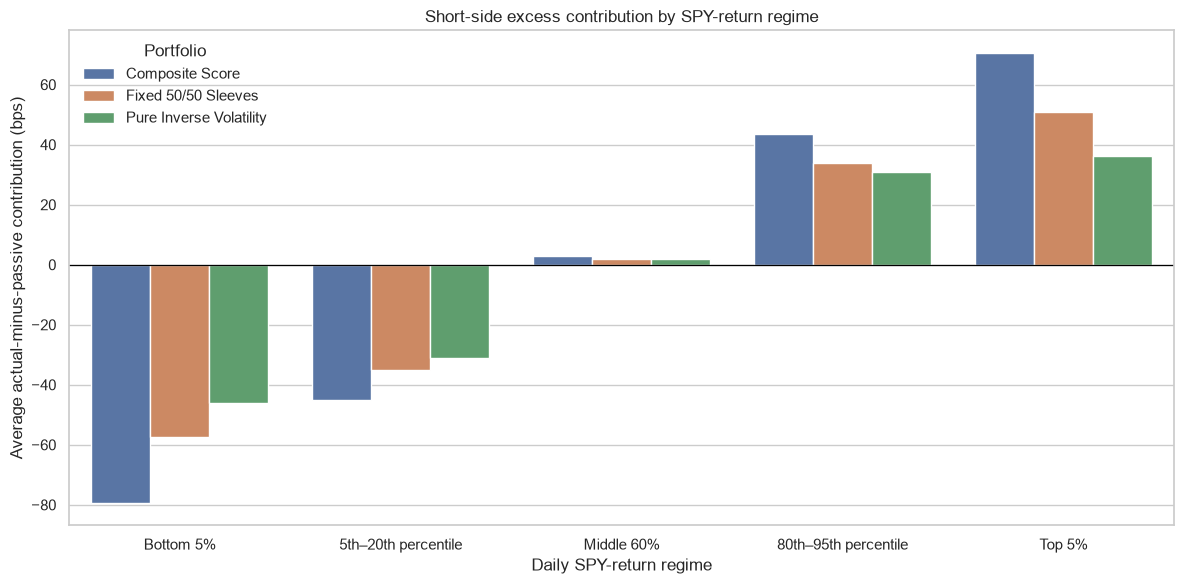

In [42]:
conditional_short_excess_plot_data = (
    conditional_short_hedge_summary[
        [
            "average_short_excess_vs_passive",
        ]
    ]
    .reset_index()
    .assign(
        average_short_excess_bps=lambda data: (
            data["average_short_excess_vs_passive"] * 10_000
        )
    )
)

fig, ax = plt.subplots(figsize=(12, 6))

sns.barplot(
    data=conditional_short_excess_plot_data,
    x="market_regime",
    y="average_short_excess_bps",
    hue="portfolio",
    order=MARKET_REGIME_ORDER,
    hue_order=PORTFOLIO_ORDER,
    errorbar=None,
    ax=ax,
)

ax.axhline(
    0.0,
    color="black",
    linewidth=0.9,
)

ax.set_title("Short-side excess contribution by SPY-return regime")
ax.set_xlabel("Daily SPY-return regime")
ax.set_ylabel("Average actual-minus-passive contribution (bps)")
ax.legend(
    title="Portfolio",
    frameon=False,
)

plt.tight_layout()
plt.show()

### Interpretation

Conditional performance confirms that the security-selected short books behave like **lower-market-beta alternatives** to passive short-SPY hedges.

During negative-market regimes, the actual short books remain strongly profitable but consistently provide less protection than same-notional short SPY. In the bottom 5% of SPY-return days, their average short excess ranges from −79.32 basis points for Composite to −46.19 basis points for Pure Inverse Volatility. Actual short excess is positive on only 7.6–21.2% of these tail observations.

The relationship reverses in rising markets. During the top 5% of SPY-return days, the actual short books lose substantially less than passive short SPY, producing average relative contributions of 36.19–70.54 basis points. Short excess is positive on 68.9–81.1% of these observations.

Pure Inverse Volatility remains the most market-like hedge. It sacrifices the least protection in negative-market regimes, consistent with its stronger stress-event hedge-efficiency ratios and higher full-sample correlation with passive short SPY. Composite exhibits the strongest trade-off: it produces the largest relative benefit in rising markets but also the largest protection shortfall in falling markets.

The bottom and top 20% regimes generate large but largely offsetting cumulative contributions. The middle 60% supplies the decisive positive residual, contributing 47.06%, 30.11% and 29.11% for Composite, Fixed 50/50 and Pure Inverse Volatility, respectively. This leads to the positive full-sample short excess reported previously.

Nevertheless, the middle-regime contribution does not by itself establish security-selection alpha. Because SPY earns a positive average return in that regime, a short basket with beta below one would mechanically lose less than short SPY. A market regression is therefore required to distinguish lower market sensitivity from beta-adjusted short-selection performance.

The regime contributions are additive arithmetic attribution measures rather than compounded standalone returns. The quantile groups are also defined ex post and should be interpreted as descriptive diagnostics.

## 9. Market-beta and short-selection attribution

The conditional results suggest that the security-selected short baskets have lower market sensitivity than SPY. This section tests that explanation formally.

The return of the underlying securities held in a short basket is reconstructed as

$$
r^{B}_{t}
=
-\frac{r^{\mathrm{short}}_t}{s_t},
$$

where $s_t$ is the portfolio's absolute short exposure. The full-sample regression is

$$
r^{B}_{t}
=
\alpha+\beta r^{\mathrm{SPY}}_t+\varepsilon_t.
$$

A market beta below one indicates that the short basket is less market-sensitive than SPY. A negative basket alpha is beneficial to the short strategy because it means that the selected securities underperform after controlling for market exposure. The reported short-selection alpha is therefore $-\alpha$.

An asymmetric specification also allows market beta to differ between positive and negative SPY-return days:

$$
r^{B}_{t}
=
\alpha
+\beta_{\mathrm{up}}r^{\mathrm{SPY}}_t
+\delta r^{\mathrm{SPY}}_t
\mathbf{1}_{\{r^{\mathrm{SPY}}_t<0\}}
+\varepsilon_t,
$$

where

$$
\beta_{\mathrm{down}}
=
\beta_{\mathrm{up}}+\delta.
$$

Newey–West heteroskedasticity- and autocorrelation-consistent standard errors are used with five lags. These are descriptive risk-attribution regressions and do not constitute a complete multi-factor alpha model.

#### Construct normalized short-basket returns

In [43]:
import statsmodels.api as sm

SHORT_EXPOSURE_TOLERANCE = 1e-12
HAC_MAX_LAGS = 5

short_beta_daily = (
    short_hedge_daily.loc[
        short_hedge_daily["short_exposure"].gt(SHORT_EXPOSURE_TOLERANCE)
    ]
    .copy()
    .sort_values(
        [
            "portfolio",
            "date",
        ]
    )
)

short_beta_daily["underlying_short_basket_return"] = (
    -short_beta_daily["short_return"] / short_beta_daily["short_exposure"]
)

if not np.isfinite(short_beta_daily["underlying_short_basket_return"]).all():
    raise ValueError("Non-finite normalized short-basket " "returns were found.")

#### Estimate full-sample beta and selection alpha

In [44]:
short_beta_regression_rows = []

for portfolio_name in PORTFOLIO_ORDER:
    portfolio_data = short_beta_daily.loc[
        short_beta_daily["portfolio"].eq(portfolio_name)
    ]

    regression_features = sm.add_constant(
        portfolio_data[
            [
                "benchmark_return",
            ]
        ],
        has_constant="add",
    )

    regression_model = sm.OLS(
        portfolio_data["underlying_short_basket_return"],
        regression_features,
    ).fit(
        cov_type="HAC",
        cov_kwds={
            "maxlags": HAC_MAX_LAGS,
        },
    )

    basket_alpha = regression_model.params["const"]
    basket_alpha_standard_error = regression_model.bse["const"]

    market_beta = regression_model.params["benchmark_return"]
    market_beta_standard_error = regression_model.bse["benchmark_return"]

    short_beta_regression_rows.append(
        {
            "portfolio": portfolio_name,
            "observations": int(regression_model.nobs),
            "annualised_short_selection_alpha": (-basket_alpha * TRADING_DAYS_PER_YEAR),
            "short_selection_alpha_hac_t_stat": (
                -basket_alpha / basket_alpha_standard_error
            ),
            "market_beta": market_beta,
            "beta_minus_one_hac_t_stat": (
                (market_beta - 1.0) / market_beta_standard_error
            ),
            "r_squared": (regression_model.rsquared),
        }
    )

short_beta_regression_summary = (
    pd.DataFrame(short_beta_regression_rows)
    .set_index("portfolio")
    .reindex(PORTFOLIO_ORDER)
)

display(
    short_beta_regression_summary.style.format(
        {
            "annualised_short_selection_alpha": ("{:.2%}"),
            "short_selection_alpha_hac_t_stat": ("{:.2f}"),
            "market_beta": "{:.3f}",
            "beta_minus_one_hac_t_stat": ("{:.2f}"),
            "r_squared": "{:.3f}",
        }
    )
)

,observations,annualised_short_selection_alpha,short_selection_alpha_hac_t_stat,market_beta,beta_minus_one_hac_t_stat,r_squared
portfolio,,,,,,
Composite Score,2635,-1.65%,-0.55,0.714,-8.10,0.653
Fixed 50/50 Sleeves,2635,-1.91%,-0.71,0.723,-7.81,0.698
Pure Inverse Volatility,2635,-1.56%,-0.58,0.796,-6.49,0.735


#### Estimate upside and downside betas

In [45]:
asymmetric_short_beta_rows = []

for portfolio_name in PORTFOLIO_ORDER:
    portfolio_data = short_beta_daily.loc[
        short_beta_daily["portfolio"].eq(portfolio_name)
    ].copy()

    portfolio_data["downside_market_return"] = portfolio_data[
        "benchmark_return"
    ] * portfolio_data["benchmark_return"].lt(0.0)

    regression_features = sm.add_constant(
        portfolio_data[
            [
                "benchmark_return",
                "downside_market_return",
            ]
        ],
        has_constant="add",
    )

    regression_model = sm.OLS(
        portfolio_data["underlying_short_basket_return"],
        regression_features,
    ).fit(
        cov_type="HAC",
        cov_kwds={
            "maxlags": HAC_MAX_LAGS,
        },
    )

    upside_beta = regression_model.params["benchmark_return"]
    downside_beta_difference = regression_model.params["downside_market_return"]
    downside_beta = upside_beta + downside_beta_difference

    parameter_covariance = regression_model.cov_params()

    downside_beta_variance = (
        parameter_covariance.loc[
            "benchmark_return",
            "benchmark_return",
        ]
        + parameter_covariance.loc[
            "downside_market_return",
            "downside_market_return",
        ]
        + 2.0
        * parameter_covariance.loc[
            "benchmark_return",
            "downside_market_return",
        ]
    )

    downside_beta_standard_error = np.sqrt(downside_beta_variance)

    asymmetric_short_beta_rows.append(
        {
            "portfolio": portfolio_name,
            "upside_market_beta": (upside_beta),
            "downside_market_beta": (downside_beta),
            "downside_minus_upside_beta": (downside_beta_difference),
            "beta_asymmetry_hac_t_stat": (
                downside_beta_difference
                / regression_model.bse["downside_market_return"]
            ),
            "upside_beta_minus_one_hac_t_stat": (
                (upside_beta - 1.0) / regression_model.bse["benchmark_return"]
            ),
            "downside_beta_minus_one_hac_t_stat": (
                (downside_beta - 1.0) / downside_beta_standard_error
            ),
            "r_squared": (regression_model.rsquared),
        }
    )

asymmetric_short_beta_summary = (
    pd.DataFrame(asymmetric_short_beta_rows)
    .set_index("portfolio")
    .reindex(PORTFOLIO_ORDER)
)

display(
    asymmetric_short_beta_summary.style.format(
        {
            "upside_market_beta": "{:.3f}",
            "downside_market_beta": "{:.3f}",
            "downside_minus_upside_beta": ("{:.3f}"),
            "beta_asymmetry_hac_t_stat": ("{:.2f}"),
            "upside_beta_minus_one_hac_t_stat": ("{:.2f}"),
            "downside_beta_minus_one_hac_t_stat": ("{:.2f}"),
            "r_squared": "{:.3f}",
        }
    )
)

,upside_market_beta,downside_market_beta,downside_minus_upside_beta,beta_asymmetry_hac_t_stat,upside_beta_minus_one_hac_t_stat,downside_beta_minus_one_hac_t_stat,r_squared
portfolio,,,,,,,
Composite Score,0.702,0.725,0.023,0.42,-8.06,-5.48,0.653
Fixed 50/50 Sleeves,0.702,0.743,0.042,0.91,-8.38,-5.51,0.698
Pure Inverse Volatility,0.789,0.803,0.015,0.32,-6.51,-4.54,0.735


### Interpretation

The regression results confirm that the security-selected short baskets have materially lower market sensitivity than SPY. Their estimated full-sample betas range from 0.714 to 0.796, and all are statistically significantly below one using Newey–West standard errors.

This lower beta explains the earlier conditional results. During rising markets, the selected short baskets lose less than same-notional short-SPY positions. During falling markets, they also gain less and therefore provide weaker protection. Because SPY earns a positive return over the full sample, the benefit in rising markets produces positive cumulative actual-minus-passive contributions despite the weaker downside hedge.

After controlling for market beta, there is no evidence of positive short-selection alpha. Estimated annualised short-selection alpha ranges from −1.56% to −1.91%, with HAC t-statistics between −0.55 and −0.71. The negative point estimates imply that the underlying selected securities slightly outperform on a beta-adjusted basis, which is unfavourable for a short strategy, but none of the estimates is statistically distinguishable from zero.

The asymmetric regressions also support a stable lower-beta explanation. Downside betas are slightly higher than upside betas, but the differences are small and statistically insignificant. There is therefore no evidence that the baskets become unusually insensitive during market declines or possess meaningful asymmetric hedge behaviour.

Pure Inverse Volatility is the most market-like of the three short implementations. It has the highest full-sample beta, the highest downside beta and the largest regression R-squared, consistent with its stronger protection during the stress-event analysis. Composite has the lowest beta and consequently exhibits the largest trade-off between reduced short-side losses in rising markets and reduced protection during sell-offs.

Overall, the selected short books provide useful portfolio diversification and materially mitigate losses during market stress, but the evidence does not support treating them as independent sources of cross-sectional alpha. Their principal economic role is that of lower-beta risk-control sleeves rather than superior substitutes for a direct market hedge.

## Conclusion

### Research question

- Does the short side provide independent cross-sectional alpha?
- Or does it primarily reduce portfolio market exposure and provide downside protection?

### 1. Performance is predominantly long-side driven

- The short books generally detract from unconditional returns over the full sample.
- This is economically unsurprising because equities experienced a positive long-run drift during the test period.
- The retained strategies should therefore not be described as receiving symmetric alpha contributions from their long and short sides.

### 2. The short side still provides meaningful downside protection

- Short-side contributions are positive in every one of the five selected major SPY drawdowns.
- All three portfolios outperform SPY during each stress event.
- Nevertheless, the protection is incomplete: most portfolio-event returns remain negative.
- The short books moderate drawdowns rather than eliminating them.

### 3. Security-selected shorts provide less crisis protection than short SPY

- Same-notional passive short-SPY positions outperform the actual short books in every stress event.
- Median hedge-efficiency ratios are:
  - **0.75** for Composite Score;
  - **0.75** for Fixed 50/50 Sleeves;
  - **0.90** for Pure Inverse Volatility.
- Pure Inverse Volatility therefore behaves most like a conventional market hedge.

### 4. Conditional performance reveals a stable lower-beta pattern

- On falling-market days, the actual short books gain less than passive short SPY.
- On rising-market days, they also lose less than passive short SPY.
- In the bottom 5% of SPY-return days, average actual-minus-passive contributions range from **−79.32 to −46.19 basis points**.
- In the top 5%, they range from **+36.19 to +70.54 basis points**.
- The positive full-sample advantage over short SPY is therefore generated by reduced losses during rising markets, partly offset by weaker protection during falling markets.

### 5. Market regressions explain the apparent advantage

- Estimated short-basket market betas range from **0.714 to 0.796**.
- All beta estimates are statistically significantly below one.
- Upside and downside betas are similar, with no statistically significant asymmetry.
- The short books therefore exhibit a relatively stable lower-beta exposure rather than a crisis-specific change in behaviour.

### 6. There is no evidence of positive beta-adjusted short-selection alpha

- Annualised short-selection alpha estimates range from **−1.56% to −1.91%**.
- HAC t-statistics range from **−0.55 to −0.71**.
- The point estimates are slightly unfavourable for the short strategies, but none is statistically distinguishable from zero.
- Positive performance relative to same-notional short SPY should therefore not be interpreted as evidence of cross-sectional short-selection skill.

### 7. The portfolio implementations serve different risk-control roles

- **Pure Inverse Volatility** is the most market-like hedge:
  - highest market and downside beta;
  - highest regression $R^2$;
  - strongest stress-event hedge efficiency.
- **Composite Score** has the lowest beta:
  - largest relative benefit during rising markets;
  - largest protection shortfall during falling markets.
- **Fixed 50/50 Sleeves** lies between these two implementations.

### Portfolio implication

- The short sleeves remain useful as sources of diversification, market-exposure reduction and downside mitigation.
- Their economic role is better described as **risk control** than as an independent source of short-side alpha.
- If market neutrality or stronger crash protection were explicit objectives, short notional should be calibrated using estimated beta rather than dollar exposure alone.

### Final takeaway

> Dollar neutrality does not imply market neutrality, and positive performance relative to a same-notional hedge does not establish security-selection skill without controlling for beta.

These results are based on a single-factor market model and a small set of ex-post stress events. A broader multi-factor attribution would be required before making stronger claims about residual security-selection alpha.

## Data exports

In [46]:
SHORT_SIDE_DAILY_EXPORT_COLUMNS = [
    "date",
    "portfolio",
    "benchmark_return",
    "short_exposure",
    "short_return",
    "passive_short_spy_contribution",
    "short_excess_vs_passive",
    "market_regime",
]

missing_daily_export_columns = set(SHORT_SIDE_DAILY_EXPORT_COLUMNS) - set(
    conditional_short_hedge_daily.columns
)

if missing_daily_export_columns:
    raise KeyError(
        "Missing columns required for the daily export: "
        f"{sorted(missing_daily_export_columns)}"
    )

short_side_daily_export = (
    conditional_short_hedge_daily[SHORT_SIDE_DAILY_EXPORT_COLUMNS]
    .copy()
    .sort_values(
        [
            "portfolio",
            "date",
        ]
    )
    .reset_index(drop=True)
)

short_side_daily_export["underlying_short_basket_return"] = (
    -short_side_daily_export["short_return"] / short_side_daily_export["short_exposure"]
)

short_side_daily_export["market_regime"] = short_side_daily_export[
    "market_regime"
].astype("string")

if not np.isfinite(short_side_daily_export["underlying_short_basket_return"]).all():
    raise ValueError(
        "The daily export contains non-finite " "normalized short-basket returns."
    )

display(short_side_daily_export.head())

,date,portfolio,benchmark_return,short_exposure,short_return,passive_short_spy_contribution,short_excess_vs_passive,market_regime,underlying_short_basket_return
0,2016-01-07,Composite Score,-0.010977,1.006390,0.007564,0.011047,-0.003483,5th–20th percentile,-0.007516
1,2016-01-08,Composite Score,0.000990,1.006618,-0.004312,-0.000997,-0.003315,Middle 60%,0.004284
2,2016-01-11,Composite Score,0.008069,1.012253,-0.005035,-0.008167,0.003132,80th–95th percentile,0.004974
3,2016-01-12,Composite Score,-0.024941,1.008633,0.014848,0.025156,-0.010308,Bottom 5%,-0.014721
4,2016-01-13,Composite Score,0.016417,1.019025,-0.011405,-0.016729,0.005324,Top 5%,0.011192


In [47]:
from pathlib import Path


def find_project_root(start_path):
    """Find the nearest parent directory containing .git."""
    start_path = Path(start_path).resolve()

    for candidate in (
        start_path,
        *start_path.parents,
    ):
        if (candidate / ".git").exists():
            return candidate

    raise FileNotFoundError(
        "Could not locate the project root " "from the current working directory."
    )


PROJECT_ROOT = find_project_root(Path.cwd())

NOTEBOOK_07_EXPORT_DIR = PROJECT_ROOT / "data" / "processed" / "notebook_07_short_side"

NOTEBOOK_07_EXPORT_DIR.mkdir(
    parents=True,
    exist_ok=True,
)


def prepare_table_for_export(table):
    """Convert meaningful indices into ordinary columns."""
    if isinstance(table.index, pd.RangeIndex) and table.index.name is None:
        return table.copy()

    return table.reset_index()


notebook_07_export_tables = {
    "07_short_side_daily.csv": (short_side_daily_export),
    "07_short_hedge_full_sample_summary.csv": (short_hedge_summary),
    "07_short_hedge_stress_detail.csv": (short_hedge_stress_detail),
    "07_short_hedge_stress_summary.csv": (short_hedge_stress_summary),
    "07_short_hedge_conditional_regimes.csv": (conditional_short_hedge_summary),
    "07_short_beta_regression_summary.csv": (short_beta_regression_summary),
    "07_short_beta_asymmetry_summary.csv": (asymmetric_short_beta_summary),
    "07_market_regime_thresholds.csv": (market_regime_thresholds),
    "07_spy_stress_event_definitions.csv": (benchmark_stress_events),
}

In [48]:
export_manifest_rows = []

for filename, table in notebook_07_export_tables.items():
    export_table = prepare_table_for_export(table)

    if export_table.columns.duplicated().any():
        duplicated_columns = export_table.columns[
            export_table.columns.duplicated()
        ].tolist()

        raise ValueError(
            f"{filename} contains duplicated columns: " f"{duplicated_columns}"
        )

    export_path = NOTEBOOK_07_EXPORT_DIR / filename

    export_table.to_csv(
        export_path,
        index=False,
        float_format="%.10g",
        date_format="%Y-%m-%d",
    )

    export_manifest_rows.append(
        {
            "filename": filename,
            "rows": len(export_table),
            "columns": len(export_table.columns),
            "file_size_kb": (export_path.stat().st_size / 1024),
            "path": str(export_path),
        }
    )

notebook_07_export_manifest = (
    pd.DataFrame(export_manifest_rows).sort_values("filename").reset_index(drop=True)
)

display(
    notebook_07_export_manifest.style.format(
        {
            "file_size_kb": "{:.1f}",
        }
    )
)

expected_export_count = len(notebook_07_export_tables)

actual_export_count = notebook_07_export_manifest["filename"].nunique()

if actual_export_count != expected_export_count:
    raise ValueError(
        "The number of exported files does " "not match the expected count."
    )

print(f"Successfully exported " f"{actual_export_count} files to:")
print(NOTEBOOK_07_EXPORT_DIR)

,filename,rows,columns,file_size_kb,path
0,07_market_regime_thresholds.csv,4,2,0.2,D:\dev\quant_projects\alpha-research-lab\data\processed\notebook_07_short_side\07_market_regime_thresholds.csv
1,07_short_beta_asymmetry_summary.csv,3,8,0.5,D:\dev\quant_projects\alpha-research-lab\data\processed\notebook_07_short_side\07_short_beta_asymmetry_summary.csv
2,07_short_beta_regression_summary.csv,3,7,0.4,D:\dev\quant_projects\alpha-research-lab\data\processed\notebook_07_short_side\07_short_beta_regression_summary.csv
3,07_short_hedge_conditional_regimes.csv,15,10,2.3,D:\dev\quant_projects\alpha-research-lab\data\processed\notebook_07_short_side\07_short_hedge_conditional_regimes.csv
4,07_short_hedge_full_sample_summary.csv,3,12,0.8,D:\dev\quant_projects\alpha-research-lab\data\processed\notebook_07_short_side\07_short_hedge_full_sample_summary.csv
5,07_short_hedge_stress_detail.csv,15,9,1.9,D:\dev\quant_projects\alpha-research-lab\data\processed\notebook_07_short_side\07_short_hedge_stress_detail.csv
6,07_short_hedge_stress_summary.csv,3,8,0.5,D:\dev\quant_projects\alpha-research-lab\data\processed\notebook_07_short_side\07_short_hedge_stress_summary.csv
7,07_short_side_daily.csv,7905,9,1044.8,D:\dev\quant_projects\alpha-research-lab\data\processed\notebook_07_short_side\07_short_side_daily.csv
8,07_spy_stress_event_definitions.csv,5,9,0.6,D:\dev\quant_projects\alpha-research-lab\data\processed\notebook_07_short_side\07_spy_stress_event_definitions.csv


Successfully exported 9 files to:
D:\dev\quant_projects\alpha-research-lab\data\processed\notebook_07_short_side
